<a href="https://colab.research.google.com/github/hawa1983/Capstone-Final-Modeling-and-Data/blob/main/dow_ridership_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Beyond the Weekday/Weekend Binary
## Day-of-Week Demand Regimes in the Post-Telework Era: Evidence from NYC Subway Turnstile Data

**Author:** Fomba Kassoh  
**Target Journal:** Transportation Research Record (TRR)  
**Date:** 2026

### Project Overview

This notebook implements the full analytical pipeline for the TRR publication examining how telework-driven behavioral change has disrupted the traditional weekday/weekend demand binary in the NYC subway system. The analysis proceeds in five stages:

1. **Data Acquisition** — MTA Turnstile data (2019, 2022, 2024) + built environment variables
2. **Data Processing** — Cleaning, aggregation, and 7-day ridership vector construction
3. **Exploratory Analysis** — Descriptive statistics and day-of-week profile visualization
4. **Cluster Analysis** — K-means typology of station demand regimes
5. **Regression Analysis** — Multinomial logistic regression explaining cluster membership

### Research Objectives
- Empirically characterize 7-day ridership profiles at NYC subway stations across three temporal periods
- Identify K-means demand regime clusters that transcend the weekday/weekend binary
- Explain cluster membership using built environment and land use variables
- Derive scheduling implications for MTA service planning

---
## SECTION 0: Environment Setup
Install all required libraries and configure global settings.

In [52]:
# ==============================================================
# Section 0.1 — Install Dependencies
# ==============================================================
# Run this cell once if working in Google Colab or a fresh environment.
# Comment out if packages are already installed.

!pip install pandas numpy scikit-learn matplotlib seaborn geopandas \
             scipy statsmodels requests tqdm plotly --quiet

In [53]:
# ==============================================================
# Section 0.2 — Import Libraries
# ==============================================================

from __future__ import annotations

import os
import re
import warnings
from io import StringIO
from pathlib import Path

import numpy as np
import pandas as pd
import requests
from tqdm import tqdm

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline

import statsmodels.api as sm
from scipy import stats

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.2f}'.format)

print("All libraries loaded successfully.")

All libraries loaded successfully.


In [54]:
# ==============================================================
# Section 0.2b — Google Colab: Mount Google Drive
# ==============================================================

from pathlib import Path

USE_DRIVE = True        # Set False if running locally

if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    OUT_DIR = Path("/content/drive/MyDrive/dow_ridership_paper/outputs")
else:
    OUT_DIR = Path("./outputs")   # local fallback

OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Output directory: {OUT_DIR}")
print(f"Drive mounted: {USE_DRIVE}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Output directory: /content/drive/MyDrive/dow_ridership_paper/outputs
Drive mounted: True


In [55]:
# ==============================================================
# Section 0.3 — Global Configuration
# ==============================================================
# Central config block — modify here, not scattered through the notebook.

import matplotlib.pyplot as plt

# ---- Study periods ----
PERIODS = {
    "precovid": {
        "label": "Pre-COVID Baseline",
        "years": [2017, 2018, 2019],
        "baseline_file": "station_daily_precovid_avg.csv",
    },
    "2022": {
        "label": "Early Recovery",
        "year": 2022,
    },
    "2024": {
        "label": "Stabilized New Normal",
        "year": 2024,
    },
}

# ---- Days of week (Mon=0, Sun=6) ----
DOW_LABELS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
DOW_MAP = {
    0: "Mon",
    1: "Tue",
    2: "Wed",
    3: "Thu",
    4: "Fri",
    5: "Sat",
    6: "Sun",
}

# ---- K-means ----
K_RANGE = range(2, 9)   # sweep K=2..8
K_FINAL = 5             # update after elbow/silhouette analysis
KMEANS_SEED = 42
KMEANS_INIT = 10        # number of random initializations

# ---- Catchment radius for built environment join ----
CATCHMENT_MILES = 0.5

# ---- Plot style ----
PALETTE = ["#1F5C99", "#E8702A", "#2E9E4F", "#C03B2B", "#7B4EA0"]

plt.rcParams.update({
    "figure.dpi": 150,
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print("Configuration complete.")

Configuration complete.


---
## SECTION 1: Data Acquisition

### 1.1 MTA Turnstile Data

The MTA publishes weekly turnstile data at `data.ny.gov`. Each row represents cumulative entries and exits for a single turnstile unit over a ~4-hour audit interval.

**Key fields:** `C/A` (control area), `UNIT`, `SCP` (subunit/channel/position), `STATION`, `LINENAME`, `DATE`, `TIME`, `ENTRIES`, `EXITS`

**Strategy:** Download all weekly files for calendar years 2019, 2022, and 2024, compute net entries per turnstile per audit period (handling counter resets), aggregate to station-day level, and then to station × day-of-week averages.

**Note on station naming:** The MTA turnstile `STATION` field does not map 1:1 to station complexes. The crosswalk from station name → station complex ID is handled in Section 2.

In [56]:
# ==============================================================
# Replacement Section — Pre-COVID Baseline from Data.NY.gov
# Uses annual archived turnstile datasets instead of old weekly MTA files
# ==============================================================

import time
import datetime
from datetime import date, timedelta
from pathlib import Path

import pandas as pd
import requests
from tqdm import tqdm


# -------------------------------------------------------
# OUTPUT LOCATION
# -------------------------------------------------------

OUT_DIR = Path("/content/drive/MyDrive/dow_ridership_paper/outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)
(OUT_DIR / "raw_turnstile").mkdir(exist_ok=True)

DOW_MAP = {
    0: "Mon",
    1: "Tue",
    2: "Wed",
    3: "Thu",
    4: "Fri",
    5: "Sat",
    6: "Sun",
}

DOW_LABELS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

PRE_COVID_YEARS = [2017, 2018, 2019]

# Official Data.NY.gov annual archived datasets
DATA_NY_DATASET_IDS = {
    2017: "v5y5-mwpb",
    2018: "bjcb-yee3",
    2019: "xfn5-qji9",
}

TURNSTILE_REQUIRED_COLS = {
    "C/A",
    "Unit",
    "SCP",
    "Station",
    "Date",
    "Time",
    "Entries",
}


# -------------------------------------------------------
# DOWNLOAD ANNUAL CSV FROM DATA.NY.GOV
# -------------------------------------------------------

def download_year_csv(year: int) -> Path:
    """
    Download annual archived turnstile CSV from Data.NY.gov.
    Saves one raw file per year:
        raw_turnstile/turnstile_2017.csv
        raw_turnstile/turnstile_2018.csv
        raw_turnstile/turnstile_2019.csv
    """
    dataset_id = DATA_NY_DATASET_IDS[year]
    url = f"https://data.ny.gov/api/views/{dataset_id}/rows.csv?accessType=DOWNLOAD"

    cache_f = OUT_DIR / "raw_turnstile" / f"turnstile_{year}.csv"

    if cache_f.exists() and cache_f.stat().st_size > 1_000_000:
        print(f"  {year}: raw annual CSV already cached: {cache_f}")
        return cache_f

    print(f"\n  {year}: downloading annual CSV from Data.NY.gov...")
    print(f"  URL: {url}")

    headers = {"User-Agent": "Mozilla/5.0"}

    with requests.get(url, headers=headers, stream=True, timeout=120) as r:
        if r.status_code != 200:
            raise RuntimeError(f"{year}: download failed with HTTP {r.status_code}")

        total = int(r.headers.get("content-length", 0))

        with open(cache_f, "wb") as f:
            if total > 0:
                pbar = tqdm(total=total, unit="B", unit_scale=True, desc=f"  {year}")
            else:
                pbar = None

            for chunk in r.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    f.write(chunk)
                    if pbar is not None:
                        pbar.update(len(chunk))

            if pbar is not None:
                pbar.close()

    # Validate columns
    test = pd.read_csv(cache_f, nrows=5, low_memory=False)
    test.columns = test.columns.str.strip()

    missing = TURNSTILE_REQUIRED_COLS - set(test.columns)
    if missing:
        raise RuntimeError(
            f"{year}: downloaded CSV is missing required columns: {missing}\n"
            f"Columns found: {list(test.columns)}"
        )

    print(f"  {year}: download complete and validated.")
    return cache_f


# -------------------------------------------------------
# BUILD STATION-DAILY PER YEAR
# -------------------------------------------------------

def build_station_daily(year: int, chunk_size: int = 750_000) -> pd.DataFrame:
    """
    Build station × date daily entries for one year.

    Uses annual Data.NY.gov CSV instead of weekly MTA text files.
    Handles the large annual files in chunks, then sorts once before diffing.
    """
    cache_out = OUT_DIR / f"station_daily_{year}.csv"

    if cache_out.exists():
        df = pd.read_csv(cache_out, parse_dates=["date"])
        print(
            f"  {year}: loaded station_daily cache — "
            f"{df['station_name'].nunique()} stations | "
            f"{df['date'].nunique()} days | "
            f"{len(df):,} rows"
        )
        return df

    raw_csv = download_year_csv(year)

    print(f"\n  {year}: reading annual CSV in chunks...")

    keep_cols = [
        "C/A",
        "Unit",
        "SCP",
        "Station",
        "Date",
        "Time",
        "Entries",
    ]

    frames = []

    reader = pd.read_csv(
        raw_csv,
        usecols=keep_cols,
        chunksize=chunk_size,
        low_memory=False,
    )

    for chunk in tqdm(reader, desc=f"  {year} chunks"):
        chunk.columns = chunk.columns.str.strip()

        chunk["DATETIME"] = pd.to_datetime(
            chunk["Date"].astype(str).str.strip() + " " +
            chunk["Time"].astype(str).str.strip(),
            format="%m/%d/%Y %H:%M:%S",
            errors="coerce",
        )

        chunk = chunk.dropna(subset=["DATETIME"])
        chunk = chunk[chunk["DATETIME"].dt.year == year].copy()

        if len(chunk) == 0:
            continue

        chunk["Entries"] = pd.to_numeric(chunk["Entries"], errors="coerce")
        chunk = chunk.dropna(subset=["Entries"])

        frames.append(
            chunk[
                [
                    "C/A",
                    "Unit",
                    "SCP",
                    "Station",
                    "DATETIME",
                    "Entries",
                ]
            ]
        )

    if not frames:
        raise RuntimeError(f"{year}: no valid records after reading annual CSV.")

    raw = pd.concat(frames, ignore_index=True)
    print(f"    Raw rows before cleaning: {len(raw):,}")

    # Sort within each physical turnstile
    unit_key = ["C/A", "Unit", "SCP"]

    raw = raw.sort_values(unit_key + ["DATETIME"]).reset_index(drop=True)

    # Compute net entries from cumulative counter
    raw["net_entries"] = (
        raw.groupby(unit_key)["Entries"]
           .diff()
           .clip(lower=0, upper=10_000)
           .fillna(0)
    )

    # Date and DOW
    raw["date"] = raw["DATETIME"].dt.normalize()
    raw["dow"] = raw["DATETIME"].dt.dayofweek
    raw["dow_label"] = raw["dow"].map(DOW_MAP)

    # Exclusion flags from your existing code
    raw["date_str"] = raw["date"].dt.strftime("%Y-%m-%d")
    raw["month_day"] = list(zip(raw["date"].dt.month, raw["date"].dt.day))

    holiday_mask = raw["month_day"].isin(HOLIDAY_MD)
    event_mask = raw["date_str"].isin(EXCLUDE_DATES)

    excluded = int((holiday_mask | event_mask).sum())

    raw = raw[~(holiday_mask | event_mask)].drop(
        columns=["date_str", "month_day"]
    ).copy()

    print(f"    Rows removed by exclusion flags: {excluded:,}")
    print(f"    Rows after exclusions:           {len(raw):,}")

    # Aggregate to station × date
    daily = (
        raw.groupby(["Station", "date", "dow", "dow_label"])["net_entries"]
           .sum()
           .reset_index()
           .rename(columns={"Station": "station_name"})
    )

    daily.to_csv(cache_out, index=False)

    print(
        f"    Final: {daily['station_name'].nunique()} stations | "
        f"{daily['date'].nunique()} days | "
        f"{len(daily):,} rows"
    )

    return daily


# -------------------------------------------------------
# BUILD 3-YEAR PRE-COVID AVERAGE
# -------------------------------------------------------

def build_precovid_average(cleaned: dict) -> pd.DataFrame:
    """
    Build 3-year averaged pre-COVID baseline:
    station × day-of-week mean entries across 2017, 2018, 2019.
    """
    cache_out = OUT_DIR / "station_daily_precovid_avg.csv"

    if cache_out.exists():
        df = pd.read_csv(cache_out)
        print(
            f"\nPre-COVID average: loaded from cache — "
            f"{df['station_name'].nunique()} stations | "
            f"{len(df):,} rows"
        )
        return df

    frames = []

    for yr in PRE_COVID_YEARS:
        if yr not in cleaned:
            print(f"  Warning: {yr} missing from cleaned dict — skipping")
            continue

        dow_agg = (
            cleaned[yr]
            .groupby(["station_name", "dow", "dow_label"])["net_entries"]
            .mean()
            .reset_index()
            .rename(columns={"net_entries": f"mean_entries_{yr}"})
        )

        frames.append(
            dow_agg.set_index(["station_name", "dow", "dow_label"])
        )

    if not frames:
        raise RuntimeError("No pre-COVID years available.")

    combined = frames[0]

    for f in frames[1:]:
        combined = combined.join(f, how="outer")

    combined = combined.reset_index()

    yr_cols = [
        f"mean_entries_{yr}"
        for yr in PRE_COVID_YEARS
        if f"mean_entries_{yr}" in combined.columns
    ]

    combined["mean_entries_precovid"] = combined[yr_cols].mean(
        axis=1,
        skipna=True,
    )

    combined["n_years_available"] = combined[yr_cols].notna().sum(axis=1)

    n_partial = int((combined["n_years_available"] < 3).sum())

    combined.to_csv(cache_out, index=False)

    print("\nPre-COVID 3-year average built:")
    print(f"  Stations:        {combined['station_name'].nunique()}")
    print(f"  DOW rows:        {len(combined):,}")
    print(f"  Full 3-yr rows:  {(combined['n_years_available'] == 3).sum():,}")
    print(f"  Partial rows:    {n_partial:,}")

    print("\nSample Monday high-volume stations:")
    sample = (
        combined[combined["dow_label"] == "Mon"]
        .nlargest(5, "mean_entries_precovid")
        [
            [
                "station_name",
                "dow_label",
                "mean_entries_precovid",
                "n_years_available",
            ]
        ]
    )

    print(sample.to_string(index=False))

    return combined


# -------------------------------------------------------
# RUN
# -------------------------------------------------------

print("\n" + "=" * 55)
print("Building pre-COVID baseline from Data.NY.gov: 2017, 2018, 2019")
print("=" * 55)

cleaned = {}

for yr in PRE_COVID_YEARS:
    cleaned[yr] = build_station_daily(yr)

print("\n" + "=" * 55)
print("Computing 3-year pre-COVID DOW average...")
print("=" * 55)

precovid_avg = build_precovid_average(cleaned)


# -------------------------------------------------------
# SUMMARY
# -------------------------------------------------------

print("\n" + "=" * 55)
print("SUMMARY")
print("=" * 55)

for yr in PRE_COVID_YEARS:
    df = cleaned[yr]

    n_st = df["station_name"].nunique()
    n_day = df["date"].nunique()
    n_rows = len(df)

    dow_counts = df.groupby("dow")["date"].nunique()
    min_days = dow_counts.min()
    max_days = dow_counts.max()

    print(f"\n  cleaned[{yr}]:")
    print(f"    Stations:          {n_st}")
    print(f"    Calendar days:     {n_day}")
    print(f"    Station-day rows:  {n_rows:,}")
    print(f"    DOW day range:     {min_days}–{max_days} days per DOW")

print("\n  precovid_avg:")
print(f"    Stations:     {precovid_avg['station_name'].nunique()}")
print(f"    Total rows:   {len(precovid_avg):,}")

print(f"\nAll files saved to: {OUT_DIR}")


Building pre-COVID baseline from Data.NY.gov: 2017, 2018, 2019
  2017: loaded station_daily cache — 380 stations | 247 days | 92,356 rows
  2018: loaded station_daily cache — 379 stations | 315 days | 117,701 rows
  2019: loaded station_daily cache — 379 stations | 285 days | 107,522 rows

Computing 3-year pre-COVID DOW average...

Pre-COVID average: loaded from cache — 381 stations | 2,662 rows

SUMMARY

  cleaned[2017]:
    Stations:          380
    Calendar days:     247
    Station-day rows:  92,356
    DOW day range:     34–36 days per DOW

  cleaned[2018]:
    Stations:          379
    Calendar days:     315
    Station-day rows:  117,701
    DOW day range:     39–48 days per DOW

  cleaned[2019]:
    Stations:          379
    Calendar days:     285
    Station-day rows:  107,522
    DOW day range:     37–44 days per DOW

  precovid_avg:
    Stations:     381
    Total rows:   2,662

All files saved to: /content/drive/MyDrive/dow_ridership_paper/outputs


### 1.2 MTA Station Complex Crosswalk

The `STATION` field in turnstile data uses MTA-internal names that do not align perfectly with official station complex IDs. We use the MTA's published station complexes file to map turnstile station names → station complex IDs, enabling consistent spatial joins with ACS and land use data.

In [57]:
# ==============================================================
# Section 1.2 — Station Complex Crosswalk
#
# Purpose:
#   Loads the MTA Subway Stations and Complexes file and
#   constructs a crosswalk between turnstile STATION names
#   and official station_complex_id values.
#
# Source: MTA Open Data / data.ny.gov
#   "MTA Subway Stations and Complexes"
#
# Output:
#   station_crosswalk_df: DataFrame with columns
#     [station_name, station_complex_id, complex_name,
#      borough, daytime_routes, complex_latitude, complex_longitude]
# ==============================================================

STATION_COMPLEX_URL = (
    "https://data.ny.gov/api/views/i9wp-a4ja/rows.csv?accessType=DOWNLOAD"
)


def load_station_complexes(url: str) -> pd.DataFrame:
    """
    Download the MTA station complexes file and return a clean DataFrame.
    """
    cache = OUT_DIR / "mta_station_complexes.csv"
    if cache.exists():
        df = pd.read_csv(cache)
    else:
        resp = requests.get(url, timeout=60)
        resp.raise_for_status()
        df = pd.read_csv(StringIO(resp.text))
        df.to_csv(cache, index=False)

    # Standardize column names to snake_case
    df.columns = (
        df.columns
          .str.strip()
          .str.lower()
          .str.replace(r"[\s/]+", "_", regex=True)
    )
    print(f"Station complexes loaded: {len(df):,} rows")
    print("Columns:", list(df.columns[:10]))
    return df


station_complex_df = load_station_complexes(STATION_COMPLEX_URL)

# ---- Preview ----
station_complex_df.head(3)

Station complexes loaded: 445 rows
Columns: ['complex_id', 'is_complex', 'number_of_stations_in_complex', 'stop_name', 'display_name', 'constituent_station_names', 'station_ids', 'gtfs_stop_ids', 'borough', 'cbd']


,complex_id,is_complex,number_of_stations_in_complex,stop_name,display_name,constituent_station_names,station_ids,gtfs_stop_ids,borough,cbd,daytime_routes,structure_type,latitude,longitude,ada,ada_notes
0,398,False,1,77 St,77 St (6),77 St,398,627,M,False,6,Subway,40.77,-73.96,0,NaN
1,399,False,1,68 St-Hunter College,68 St-Hunter College (6),68 St-Hunter College,399,628,M,False,6,Subway,40.77,-73.96,1,NaN
2,403,False,1,33 St,33 St (6),33 St,403,632,M,True,6,Subway,40.75,-73.98,0,NaN


### 1.3 Built Environment Data

We collect three categories of built environment variables:
- **ACS (Census):** Population density, median household income, vehicle ownership, commute mode share — aggregated to 0.5-mile station buffer
- **LEHD/LODES:** Job counts by sector (office vs. essential vs. retail) within 0.5-mile buffer
- **MTA Metadata:** ADA accessibility, structure type (elevated/underground), borough

In [58]:
# ==============================================================
# Section 1.3a — ACS Data via Census API
#
# Purpose:
#   Fetch block-group level ACS 5-year estimates for NYC.
#
# Output:
#   acs_bg_2019.csv
#   acs_bg_2022.csv
# ==============================================================

import time
import pandas as pd
import requests

# -------------------------------------------------------
# CENSUS API KEY
# -------------------------------------------------------
# Get a free key here:
# https://api.census.gov/data/key_signup.html
#
# Paste your key between the quotes.

CENSUS_API_KEY = "31796ddadb573a901960c3f4b507d61c1924c7f7"


# -------------------------------------------------------
# ACS VARIABLES
# -------------------------------------------------------

ACS_VARS = {
    "B01003_001E": "total_population",
    "B08201_001E": "total_households",
    "B08201_002E": "no_vehicle_hh",
    "B19013_001E": "median_hh_income",
    "B08301_001E": "total_commuters",
    "B08301_010E": "transit_commuters",
}

# NYC FIPS county codes:
# Manhattan = 061
# Bronx = 005
# Brooklyn/Kings = 047
# Queens = 081
# Staten Island/Richmond = 085

NYC_COUNTIES = ["061", "005", "047", "081", "085"]
STATE_FIPS = "36"

# ACS years:
# Use ACS 2019 for pre-COVID baseline.
# Use ACS 2022 for 2022 and 2024 analysis.
ACS_YEAR_MAP = {
    2019: 2019,
    2022: 2022,
    2024: 2022,
}


# -------------------------------------------------------
# FETCH ACS BLOCK GROUPS
# -------------------------------------------------------

def fetch_acs_block_groups(
    acs_year: int,
    state: str,
    counties: list,
    variables: dict,
    api_key: str,
    retries: int = 3,
) -> pd.DataFrame:
    """
    Fetch ACS 5-year block group estimates for NYC counties.

    Returns a DataFrame with:
        GEOID
        NAME
        total_population
        total_households
        no_vehicle_hh
        median_hh_income
        total_commuters
        transit_commuters
    """

    if api_key == "PASTE_YOUR_CENSUS_API_KEY_HERE" or not api_key.strip():
        raise ValueError(
            "You must paste your Census API key into CENSUS_API_KEY before running this cell."
        )

    cache = OUT_DIR / f"acs_bg_{acs_year}.csv"

    if cache.exists():
        print(f"  ACS {acs_year}: loaded from cache")
        return pd.read_csv(cache, dtype={"GEOID": str})

    base_url = f"https://api.census.gov/data/{acs_year}/acs/acs5"

    get_vars = ["NAME", "GEO_ID"] + list(variables.keys())

    frames = []

    for county in counties:
        print(f"  ACS {acs_year}: fetching county {county}...")

        # Use list-of-tuples so repeated "in" parameters are handled correctly.
        # Census block-group hierarchy:
        # state -> county -> tract -> block group
        params = [
            ("get", ",".join(get_vars)),
            ("for", "block group:*"),
            ("in", f"state:{state}"),
            ("in", f"county:{county}"),
            ("in", "tract:*"),
            ("key", api_key),
        ]

        success = False

        for attempt in range(retries):
            try:
                resp = requests.get(base_url, params=params, timeout=60)

                if resp.status_code != 200:
                    print(
                        f"    Attempt {attempt + 1}: county {county} "
                        f"returned HTTP {resp.status_code}"
                    )
                    print("    Response preview:")
                    print(resp.text[:500])
                    time.sleep(2 ** attempt)
                    continue

                try:
                    data = resp.json()
                except Exception as e:
                    print(
                        f"    Attempt {attempt + 1}: county {county} returned non-JSON response."
                    )
                    print(f"    JSON error: {type(e).__name__}: {e}")
                    print("    Response preview:")
                    print(resp.text[:500])
                    time.sleep(2 ** attempt)
                    continue

                if not isinstance(data, list) or len(data) < 2:
                    print(f"    County {county}: no data returned.")
                    print("    Response preview:")
                    print(str(data)[:500])
                    break

                df = pd.DataFrame(data[1:], columns=data[0])
                frames.append(df)

                print(f"    County {county}: {len(df):,} block groups")
                success = True
                break

            except Exception as e:
                print(
                    f"    Attempt {attempt + 1}: county {county} failed: "
                    f"{type(e).__name__}: {e}"
                )
                time.sleep(2 ** attempt)

        if not success:
            print(f"    Warning: county {county} was skipped.")

    if not frames:
        raise RuntimeError(
            f"ACS {acs_year}: no counties returned data. "
            "Check your Census API key, variable names, or internet access."
        )

    combined = pd.concat(frames, ignore_index=True)

    # -------------------------------------------------------
    # Build clean 12-digit block group GEOID
    # -------------------------------------------------------

    combined["GEOID"] = (
        combined["state"].astype(str).str.zfill(2)
        + combined["county"].astype(str).str.zfill(3)
        + combined["tract"].astype(str).str.zfill(6)
        + combined["block group"].astype(str)
    )

    # Rename ACS variable columns
    combined = combined.rename(columns=variables)

    # Convert ACS variables to numeric.
    # Census missing/suppressed values often appear as large negative values.
    for col in variables.values():
        combined[col] = pd.to_numeric(combined[col], errors="coerce")
        combined[col] = combined[col].where(combined[col] >= 0)

    keep_cols = ["GEOID", "NAME"] + list(variables.values())
    combined = combined[keep_cols].copy()

    combined = combined.drop_duplicates(subset=["GEOID"])

    combined.to_csv(cache, index=False)

    print(f"  ACS {acs_year}: saved {len(combined):,} block groups to {cache}")

    return combined


# -------------------------------------------------------
# RUN ACS FETCH
# -------------------------------------------------------

acs_data = {}

for acs_yr in sorted(set(ACS_YEAR_MAP.values())):
    print(f"\nFetching ACS {acs_yr}...")
    acs_data[acs_yr] = fetch_acs_block_groups(
        acs_year=acs_yr,
        state=STATE_FIPS,
        counties=NYC_COUNTIES,
        variables=ACS_VARS,
        api_key=CENSUS_API_KEY,
    )

print("\nACS fetch complete.")

for yr, df in acs_data.items():
    print(f"  ACS {yr}: {len(df):,} block groups")


Fetching ACS 2019...
  ACS 2019: loaded from cache

Fetching ACS 2022...
  ACS 2022: loaded from cache

ACS fetch complete.
  ACS 2019: 6,493 block groups
  ACS 2022: 6,807 block groups


In [59]:
# ==============================================================
# Section 1.3b — LEHD/LODES Job Data
# ==============================================================

import pandas as pd
import requests
from io import BytesIO

LODES_BASE = "https://lehd.ces.census.gov/data/lodes/LODES8/ny/wac/"

# 2019 period uses 2019 job data.
# 2022 and 2024 periods use 2021 job data.
LODES_YEARS = {
    2019: 2019,
    2022: 2021,
    2024: 2021,
}

LODES_VARS = {
    "w_geocode": "block_fips",
    "C000": "total_jobs",
    "CNS09": "finance_jobs",
    "CNS12": "professional_jobs",
    "CNS07": "retail_jobs",
    "CNS15": "healthcare_jobs",
    "CNS18": "food_service_jobs",
}


def fetch_lodes_wac(lodes_year: int) -> pd.DataFrame:
    """
    Download and cache LODES WAC file for New York State.

    WAC = Workplace Area Characteristics.
    This gives job counts by workplace location.

    Returns:
        Block-group-level job counts.
    """
    cache = OUT_DIR / f"lodes_wac_{lodes_year}.csv"

    if cache.exists():
        print(f"  LODES {lodes_year}: loaded from cache")
        return pd.read_csv(cache, dtype={"GEOID": str})

    filename = f"ny_wac_S000_JT00_{lodes_year}.csv.gz"
    url = LODES_BASE + filename

    print(f"  Downloading: {url}")

    resp = requests.get(url, timeout=120)
    resp.raise_for_status()

    # Read compressed .csv.gz content correctly
    df = pd.read_csv(
        BytesIO(resp.content),
        compression="gzip",
        dtype={"w_geocode": str},
        low_memory=False,
    )

    # Keep only variables we need
    keep_cols = [c for c in LODES_VARS.keys() if c in df.columns]
    df = df[keep_cols].copy()

    # Rename columns
    df = df.rename(columns=LODES_VARS)

    # Make sure expected job columns exist
    required_after_rename = [
        "block_fips",
        "total_jobs",
        "finance_jobs",
        "professional_jobs",
        "retail_jobs",
        "healthcare_jobs",
        "food_service_jobs",
    ]

    missing = [c for c in required_after_rename if c not in df.columns]

    if missing:
        raise RuntimeError(
            f"LODES {lodes_year}: missing expected columns: {missing}\n"
            f"Columns found: {list(df.columns)}"
        )

    # Convert job columns to numeric
    job_cols = [
        "total_jobs",
        "finance_jobs",
        "professional_jobs",
        "retail_jobs",
        "healthcare_jobs",
        "food_service_jobs",
    ]

    for col in job_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

    # Derived fields
    df["office_jobs"] = df["finance_jobs"] + df["professional_jobs"]
    df["essential_jobs"] = df["healthcare_jobs"] + df["food_service_jobs"]

    # Convert 15-digit Census block FIPS to 12-digit block group GEOID
    df["GEOID"] = df["block_fips"].astype(str).str.zfill(15).str[:12]

    # Aggregate block-level jobs to block group
    agg_cols = [
        "total_jobs",
        "finance_jobs",
        "professional_jobs",
        "retail_jobs",
        "healthcare_jobs",
        "food_service_jobs",
        "office_jobs",
        "essential_jobs",
    ]

    bg = (
        df.groupby("GEOID", as_index=False)[agg_cols]
          .sum()
    )

    bg.to_csv(cache, index=False)

    print(f"  LODES {lodes_year}: saved {len(bg):,} block groups to {cache}")

    return bg


# -------------------------------------------------------
# RUN
# -------------------------------------------------------

lodes_data = {}

for lodes_yr in sorted(set(LODES_YEARS.values())):
    print(f"\nFetching LODES {lodes_yr}...")
    lodes_data[lodes_yr] = fetch_lodes_wac(lodes_yr)

print("\nLODES fetch complete.")

for yr, df in lodes_data.items():
    print(f"  LODES {yr}: {len(df):,} block groups")


Fetching LODES 2019...
  LODES 2019: loaded from cache

Fetching LODES 2021...
  LODES 2021: loaded from cache

LODES fetch complete.
  LODES 2019: 15,698 block groups
  LODES 2021: 15,678 block groups


---
## SECTION 2: Data Processing

### 2.1 Turnstile Cleaning and Net Entry Computation

Raw MTA turnstile data records **cumulative** entry/exit counts. Net entries per audit interval must be computed by differencing consecutive readings within each `(C/A, UNIT, SCP)` turnstile unit.

**Key data quality issues:**
- **Counter resets:** Turnstile counters occasionally reset to zero or roll over. Readings that produce negative differences or implausibly large jumps (>10,000 per 4-hour period) are treated as resets and capped at zero.
- **Irregular audit intervals:** Most audits occur every ~4 hours but occasionally skipped. Net entries are normalized to a per-hour rate before aggregation.
- **Station name inconsistencies:** Resolved via the crosswalk loaded in Section 1.2.

In [69]:
# ==============================================================
# Section 2.1 — FAST Post-COVID Station-Complex Daily Ridership
#
# Purpose:
#   Downloads daily post-COVID subway ridership at station-complex level
#   from the MTA Subway Hourly Ridership dataset.
#
# Extracted years:
#   2022, 2023, 2024
#
# Main analysis:
#   2022 and 2024
#
# Robustness:
#   2023
#
# Outputs saved to Google Drive / OUT_DIR:
#   station_complex_daily_2022.csv
#   station_complex_daily_2023.csv
#   station_complex_daily_2024.csv
#   station_complex_daily_main_2022_2024.csv
#   station_complex_daily_robustness_2023.csv
# ==============================================================

import time
import io
from pathlib import Path

import pandas as pd
import numpy as np
import requests


# -------------------------------------------------------
# Recover required globals
# -------------------------------------------------------

if "OUT_DIR" not in globals():
    OUT_DIR = Path("/content/drive/MyDrive/dow_ridership_paper/outputs")
    print(f"OUT_DIR recovered: {OUT_DIR}")

OUT_DIR.mkdir(parents=True, exist_ok=True)

if "DOW_MAP" not in globals():
    DOW_MAP = {
        0: "Mon",
        1: "Tue",
        2: "Wed",
        3: "Thu",
        4: "Fri",
        5: "Sat",
        6: "Sun",
    }

if "DOW_LABELS" not in globals():
    DOW_LABELS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]


# -------------------------------------------------------
# Settings
# -------------------------------------------------------

DEBUG = True

def _log(msg):
    if DEBUG:
        print(msg, flush=True)


SESSION = requests.Session()
SESSION.headers.update(
    {
        "User-Agent": "Mozilla/5.0",
        "Accept-Encoding": "gzip, deflate",
    }
)

TIMEOUT = 180
MAX_RETRIES = 6
BACKOFF_BASE_SEC = 2.0

POST_BASE_URL = "https://data.ny.gov/resource/wujg-7c2s.csv"

POST_COVID_YEARS = [2022, 2023, 2024]
MAIN_MODEL_YEARS = [2022, 2024]
ROBUSTNESS_YEARS = [2023]

# -------------------------------------------------------
# One-time refresh setting
# -------------------------------------------------------
# Set True for this one run to redownload/rebuild files.
# After the files are successfully saved, change this to False
# so future notebook runs load from cache.

FORCE_REFRESH_POSTCOVID = False


# -------------------------------------------------------
# Network helper
# -------------------------------------------------------

def _request_csv(url: str, params: dict) -> pd.DataFrame:
    """
    Request a CSV from Data.NY.gov with retries.
    """

    last_err = None

    for attempt in range(MAX_RETRIES):
        try:
            r = SESSION.get(url, params=params, timeout=TIMEOUT)

            if r.status_code in (429, 500, 502, 503, 504):
                sleep_s = BACKOFF_BASE_SEC * (2 ** attempt)
                _log(
                    f"Retryable status {r.status_code}; "
                    f"sleeping {sleep_s:.1f}s"
                )
                time.sleep(sleep_s)
                continue

            if 400 <= r.status_code < 500:
                print("Request URL:")
                print(r.url)
                print("Response preview:")
                print(r.text[:1000])
                r.raise_for_status()

            r.raise_for_status()

            return pd.read_csv(io.StringIO(r.text))

        except requests.HTTPError as e:
            last_err = e
            raise

        except Exception as e:
            last_err = e
            sleep_s = BACKOFF_BASE_SEC * (2 ** attempt)
            _log(
                f"Request failed on attempt {attempt + 1}/{MAX_RETRIES}; "
                f"sleeping {sleep_s:.1f}s"
            )
            time.sleep(sleep_s)

    raise RuntimeError(f"Request failed after retries. Last error: {last_err}")


# -------------------------------------------------------
# Fetch one year
# -------------------------------------------------------

def fetch_station_complex_daily_post(year: int) -> pd.DataFrame:
    """
    Pull already-aggregated daily ridership for one year from
    the post-COVID MTA hourly ridership dataset.

    Output level:
        station_complex_id × date
    """

    cache = OUT_DIR / f"station_complex_daily_{year}.csv"

    if cache.exists() and not FORCE_REFRESH_POSTCOVID:
        print(f"  {year}: loaded station-complex daily from cache")
        return pd.read_csv(cache, parse_dates=["date"])

    if cache.exists() and FORCE_REFRESH_POSTCOVID:
        print(
            f"  {year}: cache exists, but FORCE_REFRESH_POSTCOVID=True, "
            "so redownloading..."
        )

    start_iso = f"{year}-01-01"
    end_iso = f"{year + 1}-01-01"

    params = {
        "$select": (
            "date_trunc_ymd(transit_timestamp) AS date, "
            "station_complex_id, "
            "station_complex, "
            "borough, "
            "sum(ridership) AS net_entries"
        ),
        "$where": (
            f"transit_timestamp >= '{start_iso}T00:00:00.000' "
            f"AND transit_timestamp < '{end_iso}T00:00:00.000'"
        ),
        "$group": "date, station_complex_id, station_complex, borough",
        "$limit": 500000,
    }

    _log(f"POST {year}: fetching grouped daily ridership...")

    df = _request_csv(POST_BASE_URL, params)

    if df.empty:
        raise RuntimeError(f"{year}: no post-COVID ridership rows returned.")

    # -------------------------------------------------------
    # Clean columns
    # -------------------------------------------------------

    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(r"[\s/]+", "_", regex=True)
    )

    required_cols = {
        "date",
        "station_complex_id",
        "station_complex",
        "net_entries",
    }

    missing = required_cols - set(df.columns)

    if missing:
        raise RuntimeError(
            f"{year}: missing expected columns: {missing}\n"
            f"Columns found: {list(df.columns)}"
        )

    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    df["station_complex_id"] = pd.to_numeric(
        df["station_complex_id"],
        errors="coerce"
    )

    df["station_complex"] = df["station_complex"].astype(str).str.strip()

    if "borough" in df.columns:
        df["borough"] = df["borough"].astype(str).str.strip()
        df.loc[df["borough"].str.lower() == "nan", "borough"] = np.nan
        df.loc[df["borough"] == "", "borough"] = np.nan
    else:
        df["borough"] = np.nan

    df["net_entries"] = pd.to_numeric(
        df["net_entries"],
        errors="coerce"
    ).fillna(0)

    df = df.dropna(
        subset=["date", "station_complex_id", "station_complex"]
    ).copy()

    # Add day-of-week
    df["dow"] = df["date"].dt.dayofweek
    df["dow_label"] = df["dow"].map(DOW_MAP)

    # Rename for consistency with the rest of the notebook
    df = df.rename(columns={"station_complex": "complex_name"})

    # Final safety aggregation
    df = (
        df.groupby(
            [
                "station_complex_id",
                "complex_name",
                "borough",
                "date",
                "dow",
                "dow_label",
            ],
            as_index=False,
        )
        .agg(
            net_entries=("net_entries", "sum")
        )
    )

    # Save individual year file
    df.to_csv(cache, index=False)

    print(
        f"  {year}: saved {len(df):,} rows | "
        f"{df['station_complex_id'].nunique()} complexes | "
        f"{df['date'].nunique()} days"
    )
    print(f"  Saved file: {cache}")

    return df


# -------------------------------------------------------
# Run extraction for 2022, 2023, and 2024
# -------------------------------------------------------

station_complex_daily = {}

for yr in POST_COVID_YEARS:
    print(f"\nFetching post-COVID daily ridership for {yr}...")
    station_complex_daily[yr] = fetch_station_complex_daily_post(yr)

print("\nPost-COVID station-complex daily ridership extraction complete.")

for yr, df in station_complex_daily.items():
    print(
        f"  {yr}: {df['station_complex_id'].nunique()} complexes, "
        f"{df['date'].nunique()} days, {len(df):,} rows"
    )


# -------------------------------------------------------
# Save main modeling dataset: 2022 and 2024
# -------------------------------------------------------

main_model_daily = pd.concat(
    [
        station_complex_daily[yr].assign(period_year=yr)
        for yr in MAIN_MODEL_YEARS
    ],
    ignore_index=True,
)

main_model_out = OUT_DIR / "station_complex_daily_main_2022_2024.csv"

main_model_daily.to_csv(main_model_out, index=False)

print("\nMain modeling dataset saved:")
print(f"  File: {main_model_out}")
print(f"  Rows: {len(main_model_daily):,}")
print(f"  Years: {sorted(main_model_daily['period_year'].unique())}")
print(f"  Complexes: {main_model_daily['station_complex_id'].nunique()}")


# -------------------------------------------------------
# Save robustness dataset: 2023
# -------------------------------------------------------

robustness_daily_2023 = station_complex_daily[2023].assign(period_year=2023)

robustness_out = OUT_DIR / "station_complex_daily_robustness_2023.csv"

robustness_daily_2023.to_csv(robustness_out, index=False)

print("\nRobustness dataset saved:")
print(f"  File: {robustness_out}")
print(f"  Rows: {len(robustness_daily_2023):,}")
print(f"  Years: {sorted(robustness_daily_2023['period_year'].unique())}")
print(f"  Complexes: {robustness_daily_2023['station_complex_id'].nunique()}")


# -------------------------------------------------------
# Verify files were saved
# -------------------------------------------------------

print("\n================ POST-COVID FILE SAVE CHECK ================\n")

files_to_check = [
    OUT_DIR / "station_complex_daily_2022.csv",
    OUT_DIR / "station_complex_daily_2023.csv",
    OUT_DIR / "station_complex_daily_2024.csv",
    OUT_DIR / "station_complex_daily_main_2022_2024.csv",
    OUT_DIR / "station_complex_daily_robustness_2023.csv",
]

for path in files_to_check:
    print(f"{path.name}: exists={path.exists()} | {path}")


# -------------------------------------------------------
# Quick QA checks
# -------------------------------------------------------

print("\n================ POST-COVID QA CHECKS ================\n")

for yr, df in station_complex_daily.items():
    print(f"\nYear: {yr}")
    print("-" * 50)
    print("Rows:", len(df))
    print("Unique station complexes:", df["station_complex_id"].nunique())
    print("Unique dates:", df["date"].nunique())
    print("Date range:", df["date"].min(), "to", df["date"].max())
    print("Total net entries:", df["net_entries"].sum())

    print("\nMissing values:")
    print(
        df[
            [
                "station_complex_id",
                "complex_name",
                "borough",
                "date",
                "net_entries",
            ]
        ].isna().sum()
    )

print("\nAverage daily net entries by year:")

combined_postcovid_check = pd.concat(
    [
        station_complex_daily[yr].assign(period_year=yr)
        for yr in POST_COVID_YEARS
    ],
    ignore_index=True,
)

print(
    combined_postcovid_check
    .groupby("period_year")["net_entries"]
    .mean()
)


Fetching post-COVID daily ridership for 2022...
  2022: loaded station-complex daily from cache

Fetching post-COVID daily ridership for 2023...
  2023: loaded station-complex daily from cache

Fetching post-COVID daily ridership for 2024...
  2024: loaded station-complex daily from cache

Post-COVID station-complex daily ridership extraction complete.
  2022: 426 complexes, 365 days, 155,248 rows
  2023: 426 complexes, 365 days, 155,238 rows
  2024: 426 complexes, 366 days, 155,634 rows

Main modeling dataset saved:
  File: /content/drive/MyDrive/dow_ridership_paper/outputs/station_complex_daily_main_2022_2024.csv
  Rows: 310,882
  Years: [np.int64(2022), np.int64(2024)]
  Complexes: 426

Robustness dataset saved:
  File: /content/drive/MyDrive/dow_ridership_paper/outputs/station_complex_daily_robustness_2023.csv
  Rows: 155,238
  Years: [np.int64(2023)]
  Complexes: 426

================ POST-COVID FILE SAVE CHECK ================

station_complex_daily_2022.csv: exists=True | /cont

### 2.2 Station Complex Join

Join cleaned turnstile data to station complex IDs using the MTA crosswalk. Station names in turnstile data are fuzzy-matched to complex names where exact matches fail.

In [70]:
# ==============================================================
# Section 2.2 — Pre-COVID Station Name → Complex ID Join
#
# Purpose:
#   Converts the 2017–2019 pre-COVID station-level baseline into
#   station-complex-level baseline data.
#
# Input:
#   station_daily_precovid_avg.csv
#
# Required existing object:
#   station_complex_df
#
# Outputs:
#   station_daily_precovid_with_complex.csv
#   station_complex_precovid_avg.csv
#
# Note:
#   Post-COVID 2022, 2023, and 2024 data already comes from the
#   MTA hourly ridership dataset at station-complex level, so it
#   does not need this station-name join.
# ==============================================================

import re
import difflib
import pandas as pd
import numpy as np


# -------------------------------------------------------
# Helper: normalize station names
# -------------------------------------------------------

def normalize_name(name: str) -> str:
    """
    Lowercase, remove punctuation, collapse whitespace.
    """
    name = str(name).lower()
    name = re.sub(r"[^a-z0-9 ]", " ", name)
    name = re.sub(r"\s+", " ", name).strip()
    return name


# -------------------------------------------------------
# Build flexible crosswalk
# -------------------------------------------------------

def build_crosswalk(complex_df: pd.DataFrame) -> pd.DataFrame:
    """
    Build a flexible station-name → complex_id crosswalk from the
    station complex file.

    Compatible with columns:
      complex_id
      stop_name
      display_name
      constituent_station_names
      latitude
      longitude

    The matching keys are built from:
      1. display_name
      2. stop_name
      3. constituent_station_names
    """

    df = complex_df.copy()
    df.columns = df.columns.str.strip().str.lower()

    required = {"complex_id", "display_name", "latitude", "longitude"}
    missing = required - set(df.columns)

    if missing:
        raise RuntimeError(
            f"Missing required crosswalk columns: {missing}\n"
            f"Columns found: {list(df.columns)}"
        )

    alias_rows = []

    for _, row in df.iterrows():
        complex_id = row.get("complex_id")
        display_name = row.get("display_name")
        stop_name = row.get("stop_name")
        constituent_names = row.get("constituent_station_names")
        lat = row.get("latitude")
        lon = row.get("longitude")

        aliases = []

        # Official display/complex name
        if pd.notna(display_name):
            aliases.append(str(display_name))

        # Stop-level name variant
        if "stop_name" in df.columns and pd.notna(stop_name):
            aliases.append(str(stop_name))

        # Additional names inside the complex
        if "constituent_station_names" in df.columns and pd.notna(constituent_names):
            parts = re.split(r"[;,/]", str(constituent_names))
            aliases.extend([p.strip() for p in parts if p.strip()])

        # Remove blanks
        aliases = [a.strip() for a in aliases if str(a).strip()]

        for alias in aliases:
            alias_rows.append(
                {
                    "station_complex_id": complex_id,
                    "complex_name": display_name,
                    "complex_lat": lat,
                    "complex_lon": lon,
                    "alias_name": alias,
                    "key": normalize_name(alias),
                }
            )

    xwalk = pd.DataFrame(alias_rows)

    if xwalk.empty:
        raise RuntimeError("Crosswalk alias table is empty. Check station_complex_df.")

    xwalk["station_complex_id"] = pd.to_numeric(
        xwalk["station_complex_id"],
        errors="coerce"
    )

    xwalk["complex_lat"] = pd.to_numeric(
        xwalk["complex_lat"],
        errors="coerce"
    )

    xwalk["complex_lon"] = pd.to_numeric(
        xwalk["complex_lon"],
        errors="coerce"
    )

    xwalk["complex_name"] = xwalk["complex_name"].astype(str).str.strip()
    xwalk["alias_name"] = xwalk["alias_name"].astype(str).str.strip()

    xwalk = xwalk.dropna(subset=["station_complex_id"])
    xwalk = xwalk[xwalk["key"].notna() & (xwalk["key"] != "")].copy()

    # Keep one row per normalized alias key
    xwalk = xwalk.drop_duplicates(subset=["key"])

    print(f"Crosswalk built: {len(xwalk):,} unique station-name keys")
    print(f"Complexes in crosswalk: {xwalk['station_complex_id'].nunique()}")

    return xwalk


# -------------------------------------------------------
# Join station-level pre-COVID baseline to complex IDs
# -------------------------------------------------------

def join_complex(
    daily_df: pd.DataFrame,
    xwalk: pd.DataFrame,
    fuzzy_cutoff: float = 0.75
) -> pd.DataFrame:
    """
    Join station-level pre-COVID baseline to station-complex crosswalk.
    Uses exact normalized-name matching first, then fuzzy matching.
    """

    daily_df = daily_df.copy()

    if "station_name" not in daily_df.columns:
        raise RuntimeError(
            "Input dataframe must contain station_name.\n"
            f"Columns found: {list(daily_df.columns)}"
        )

    daily_df["key"] = daily_df["station_name"].apply(normalize_name)

    exact_map = (
        xwalk
        .set_index("key")[["station_complex_id", "complex_name", "complex_lat", "complex_lon"]]
        .to_dict("index")
    )

    unmatched_keys = set(daily_df["key"].unique()) - set(exact_map.keys())
    all_xwalk_keys = list(exact_map.keys())

    fuzzy_map = {}

    for ukey in unmatched_keys:
        matches = difflib.get_close_matches(
            ukey,
            all_xwalk_keys,
            n=1,
            cutoff=fuzzy_cutoff
        )

        if matches:
            fuzzy_map[ukey] = exact_map[matches[0]]

    combined_map = {**exact_map, **fuzzy_map}

    still_unmatched = set(daily_df["key"].unique()) - set(combined_map.keys())

    if still_unmatched:
        print(f"\nWarning: {len(still_unmatched)} station names unmatched.")
        print("First 25 unmatched station keys:")
        for s in sorted(still_unmatched)[:25]:
            print(f"  {s}")

    daily_df["station_complex_id"] = daily_df["key"].map(
        lambda k: combined_map.get(k, {}).get("station_complex_id")
    )

    daily_df["complex_name"] = daily_df["key"].map(
        lambda k: combined_map.get(k, {}).get("complex_name")
    )

    daily_df["complex_lat"] = daily_df["key"].map(
        lambda k: combined_map.get(k, {}).get("complex_lat")
    )

    daily_df["complex_lon"] = daily_df["key"].map(
        lambda k: combined_map.get(k, {}).get("complex_lon")
    )

    before = len(daily_df)

    daily_df = daily_df.dropna(subset=["station_complex_id"]).copy()

    after = len(daily_df)

    print("\nJoin results:")
    print(f"  Rows before join drop: {before:,}")
    print(f"  Rows after join drop:  {after:,}")
    print(f"  Rows dropped:          {before - after:,}")
    print(f"  Complexes retained:    {daily_df['station_complex_id'].nunique()}")

    daily_df = daily_df.drop(columns=["key"])

    return daily_df


# -------------------------------------------------------
# Build crosswalk
# -------------------------------------------------------

xwalk_df = build_crosswalk(station_complex_df)


# -------------------------------------------------------
# Load pre-COVID station-level baseline
# -------------------------------------------------------

precovid_avg_path = OUT_DIR / "station_daily_precovid_avg.csv"

if not precovid_avg_path.exists():
    raise FileNotFoundError(
        f"Missing file: {precovid_avg_path}\n"
        "Run the pre-COVID 2017–2019 baseline creation section first."
    )

precovid_avg = pd.read_csv(precovid_avg_path)

print("\nPre-COVID station-level baseline loaded:")
print(f"  File: {precovid_avg_path}")
print(f"  Rows: {len(precovid_avg):,}")
print(f"  Station names: {precovid_avg['station_name'].nunique()}")


# -------------------------------------------------------
# Join pre-COVID baseline to station complex
# -------------------------------------------------------

precovid_with_complex = join_complex(
    precovid_avg,
    xwalk_df,
    fuzzy_cutoff=0.75
)

precovid_with_complex_out = OUT_DIR / "station_daily_precovid_with_complex.csv"

precovid_with_complex.to_csv(
    precovid_with_complex_out,
    index=False
)

print("\nPre-COVID station-level baseline with complex IDs saved:")
print(f"  File: {precovid_with_complex_out}")
print(f"  Rows: {len(precovid_with_complex):,}")
print(f"  Complexes: {precovid_with_complex['station_complex_id'].nunique()}")


# -------------------------------------------------------
# Aggregate pre-COVID baseline to station-complex × DOW
# -------------------------------------------------------

required_precovid_cols = [
    "mean_entries_2017",
    "mean_entries_2018",
    "mean_entries_2019",
    "mean_entries_precovid",
]

missing_precovid_cols = [
    c for c in required_precovid_cols
    if c not in precovid_with_complex.columns
]

if missing_precovid_cols:
    raise RuntimeError(
        f"Missing expected pre-COVID mean-entry columns: {missing_precovid_cols}\n"
        f"Columns found: {list(precovid_with_complex.columns)}"
    )

required_group_cols = [
    "station_complex_id",
    "complex_name",
    "complex_lat",
    "complex_lon",
    "dow",
    "dow_label",
]

missing_group_cols = [
    c for c in required_group_cols
    if c not in precovid_with_complex.columns
]

if missing_group_cols:
    raise RuntimeError(
        f"Missing expected grouping columns: {missing_group_cols}\n"
        f"Columns found: {list(precovid_with_complex.columns)}"
    )

precovid_complex_avg = (
    precovid_with_complex
    .groupby(
        [
            "station_complex_id",
            "complex_name",
            "complex_lat",
            "complex_lon",
            "dow",
            "dow_label",
        ],
        as_index=False
    )
    .agg(
        mean_entries_2017=("mean_entries_2017", "sum"),
        mean_entries_2018=("mean_entries_2018", "sum"),
        mean_entries_2019=("mean_entries_2019", "sum"),
        mean_entries_precovid=("mean_entries_precovid", "sum"),
        n_station_names=("station_name", "nunique"),
    )
)

precovid_complex_avg_out = OUT_DIR / "station_complex_precovid_avg.csv"

precovid_complex_avg.to_csv(
    precovid_complex_avg_out,
    index=False
)

print("\nPre-COVID baseline aggregated to station-complex level:")
print(f"  File: {precovid_complex_avg_out}")
print(f"  Rows: {len(precovid_complex_avg):,}")
print(f"  Complexes: {precovid_complex_avg['station_complex_id'].nunique()}")
print(f"  DOW values: {sorted(precovid_complex_avg['dow_label'].dropna().unique())}")


# -------------------------------------------------------
# QA checks
# -------------------------------------------------------

print("\n================ PRE-COVID COMPLEX BASELINE QA ================\n")

print("Rows by DOW:")
print(
    precovid_complex_avg
    .groupby(["dow", "dow_label"])
    .size()
    .reset_index(name="rows")
    .sort_values("dow")
)

print("\nAverage pre-COVID entries by DOW:")
print(
    precovid_complex_avg
    .groupby(["dow", "dow_label"])["mean_entries_precovid"]
    .mean()
    .reset_index()
    .sort_values("dow")
)

print("\nTop 10 complexes by pre-COVID average entries:")
display(
    precovid_complex_avg
    .groupby(["station_complex_id", "complex_name"], as_index=False)
    ["mean_entries_precovid"]
    .mean()
    .sort_values("mean_entries_precovid", ascending=False)
    .head(10)
)

Crosswalk built: 840 unique station-name keys
Complexes in crosswalk: 445

Pre-COVID station-level baseline loaded:
  File: /content/drive/MyDrive/dow_ridership_paper/outputs/station_daily_precovid_avg.csv
  Rows: 2,662
  Station names: 381

First 25 unmatched station keys:
  116 st columbia
  14th street
  42 st port auth
  47 50 sts rock
  81 st museum
  86 st 2 ave
  96 st 2 ave
  9th street
  atl av barclay
  bushwick av
  central pk n110
  christopher st
  city bus
  eastn pkwy musm
  exchange place
  flatbush av b c
  grove street
  harrison
  howard bch jfk
  hoyt scher
  jfk jamaica ct1
  journal square
  kew gardens
  lackawanna
  newark bm bw

Join results:
  Rows before join drop: 2,662
  Rows after join drop:  2,380
  Rows dropped:          282
  Complexes retained:    319

Pre-COVID station-level baseline with complex IDs saved:
  File: /content/drive/MyDrive/dow_ridership_paper/outputs/station_daily_precovid_with_complex.csv
  Rows: 2,380
  Complexes: 319

Pre-COVID basel

,station_complex_id,complex_name,mean_entries_precovid
177,318.00,"34 St-Penn Station (1,2,3)","153,442.17"
297,610.00,"Grand Central-42 St (4,5,6,7,S)","130,699.45"
294,607.00,"34 St-Herald Sq (B,D,F,M,N,Q,R,W)","105,947.41"
178,320.00,23 St (1),"103,970.80"
289,602.00,"14 St-Union Sq (4,5,6,L,N,Q,R,W)","97,367.47"
298,611.00,"Times Sq-42 St/Port Authority Bus Terminal (1,...","93,004.57"
314,628.00,"Fulton St (2,3,4,5,A,C,J,Z)","87,463.15"
284,476.00,86 St (Q),"79,034.74"
308,622.00,"Brooklyn Bridge-City Hall/Chambers St (4,5,6,J,Z)","72,727.86"
261,439.00,"125 St (2,3)","70,943.52"


### 2.3 7-Day Ridership Vector Construction

The core analytical unit is a **7-dimensional normalized ridership vector** per station per period.

For each station-complex:
1. Compute the mean daily entries for each of the 7 days of week across the full study year
2. Normalize by the station's total weekly volume (sum across all 7 days = 1.0)

Normalization ensures clustering captures **demand shape** (when people ride) rather than **scale** (how many ride). A large hub station and a small neighborhood station can share the same demand regime.

In [77]:
# ==============================================================
# Section 2.3 — 7-Day Ridership Vector Construction
#
# Purpose:
#   Converts station-complex ridership data to normalized 7-day
#   ridership vectors for K-means clustering.
#
# Inputs:
#   Pre-COVID:
#     station_complex_precovid_avg.csv
#
#   Post-COVID:
#     station_complex_daily_2022.csv
#     station_complex_daily_2023.csv
#     station_complex_daily_2024.csv
#
# Outputs:
#   dow_vectors_precovid.csv
#   dow_raw_precovid.csv
#   dow_vectors_2022.csv
#   dow_raw_2022.csv
#   dow_vectors_2023.csv
#   dow_raw_2023.csv
#   dow_vectors_2024.csv
#   dow_raw_2024.csv
# ==============================================================

import pandas as pd
import numpy as np


# -------------------------------------------------------
# DOW label setup
# -------------------------------------------------------

DOW_MAP_FULL = {
    0: "Mon",
    1: "Tue",
    2: "Wed",
    3: "Thu",
    4: "Fri",
    5: "Sat",
    6: "Sun",
}

DOW_LABELS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]


# -------------------------------------------------------
# Optional: delete old/bad post-COVID DOW cache files
# -------------------------------------------------------
# This is important because the earlier version created empty files
# for 2022, 2023, and 2024.

DELETE_BAD_POSTCOVID_DOW_CACHE = True

if DELETE_BAD_POSTCOVID_DOW_CACHE:
    for yr in [2022, 2023, 2024]:
        for prefix in ["dow_raw", "dow_vectors"]:
            path = OUT_DIR / f"{prefix}_{yr}.csv"
            if path.exists():
                path.unlink()
                print(f"Deleted old post-COVID DOW cache: {path}")


# -------------------------------------------------------
# Build DOW vectors from post-COVID daily data
# -------------------------------------------------------

def build_dow_vectors_from_daily(
    daily_df: pd.DataFrame,
    label: str
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Build normalized and raw day-of-week ridership vectors from
    station-complex daily data.

    Expected input columns:
      station_complex_id
      complex_name
      dow
      net_entries

    Optional:
      borough
    """

    cache_norm = OUT_DIR / f"dow_vectors_{label}.csv"
    cache_raw = OUT_DIR / f"dow_raw_{label}.csv"

    if cache_norm.exists() and cache_raw.exists():
        print(f"  {label}: loaded DOW vectors from cache")
        return (
            pd.read_csv(cache_norm),
            pd.read_csv(cache_raw),
        )

    df = daily_df.copy()

    required_cols = {
        "station_complex_id",
        "complex_name",
        "dow",
        "net_entries",
    }

    missing = required_cols - set(df.columns)

    if missing:
        raise RuntimeError(
            f"{label}: missing required columns: {missing}\n"
            f"Columns found: {list(df.columns)}"
        )

    df["station_complex_id"] = pd.to_numeric(
        df["station_complex_id"],
        errors="coerce"
    )

    df["complex_name"] = df["complex_name"].astype(str).str.strip()

    df["dow"] = pd.to_numeric(
        df["dow"],
        errors="coerce"
    )

    df["net_entries"] = pd.to_numeric(
        df["net_entries"],
        errors="coerce"
    ).fillna(0)

    if "borough" not in df.columns:
        df["borough"] = "Unknown"

    df["borough"] = df["borough"].fillna("Unknown").astype(str).str.strip()

    df = df.dropna(
        subset=["station_complex_id", "complex_name", "dow"]
    ).copy()

    # Keep only valid DOW values
    df = df[df["dow"].isin(range(7))].copy()
    df["dow"] = df["dow"].astype(int)

    # -------------------------------------------------------
    # IMPORTANT:
    # Do not group by complex_lat/complex_lon here.
    # The post-COVID files may not have them, and grouping on
    # all-NaN coordinate columns makes pandas drop every row.
    # -------------------------------------------------------

    group_cols = [
        "station_complex_id",
        "complex_name",
        "borough",
        "dow",
    ]

    agg = (
        df
        .groupby(group_cols, as_index=False)
        .agg(mean_entries=("net_entries", "mean"))
    )

    raw = (
        agg
        .pivot_table(
            index=[
                "station_complex_id",
                "complex_name",
                "borough",
            ],
            columns="dow",
            values="mean_entries",
        )
        .reset_index()
    )

    raw = raw.rename(columns=DOW_MAP_FULL)

    for col in DOW_LABELS:
        if col not in raw.columns:
            raw[col] = np.nan

    raw = raw.dropna(subset=DOW_LABELS).copy()

    norm = raw.copy()

    row_sums = norm[DOW_LABELS].sum(axis=1)

    nonzero = row_sums > 0
    raw = raw.loc[nonzero].copy()
    norm = norm.loc[nonzero].copy()
    row_sums = row_sums.loc[nonzero]

    norm[DOW_LABELS] = norm[DOW_LABELS].div(row_sums, axis=0)

    weekday_cols = ["Mon", "Tue", "Wed", "Thu", "Fri"]

    raw["avg_weekday_entries"] = raw[weekday_cols].mean(axis=1)
    raw["low_volume_flag"] = raw["avg_weekday_entries"] < 50

    norm["avg_weekday_entries"] = raw["avg_weekday_entries"].values
    norm["low_volume_flag"] = raw["low_volume_flag"].values

    raw.to_csv(cache_raw, index=False)
    norm.to_csv(cache_norm, index=False)

    print(
        f"  {label}: {len(norm):,} complexes | "
        f"{int(norm['low_volume_flag'].sum())} low-volume flagged"
    )

    return norm, raw


# -------------------------------------------------------
# Build DOW vectors from pre-COVID complex average
# -------------------------------------------------------

def build_dow_vectors_from_precovid_avg(
    precovid_df: pd.DataFrame,
    label: str = "precovid"
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Build normalized and raw DOW vectors from the pre-COVID station-complex
    average file.

    Expected input columns:
      station_complex_id
      complex_name
      complex_lat
      complex_lon
      dow
      mean_entries_precovid
    """

    cache_norm = OUT_DIR / f"dow_vectors_{label}.csv"
    cache_raw = OUT_DIR / f"dow_raw_{label}.csv"

    if cache_norm.exists() and cache_raw.exists():
        print(f"  {label}: loaded DOW vectors from cache")
        return (
            pd.read_csv(cache_norm),
            pd.read_csv(cache_raw),
        )

    df = precovid_df.copy()

    required_cols = {
        "station_complex_id",
        "complex_name",
        "complex_lat",
        "complex_lon",
        "dow",
        "mean_entries_precovid",
    }

    missing = required_cols - set(df.columns)

    if missing:
        raise RuntimeError(
            f"{label}: missing required columns: {missing}\n"
            f"Columns found: {list(df.columns)}"
        )

    df["station_complex_id"] = pd.to_numeric(
        df["station_complex_id"],
        errors="coerce"
    )

    df["complex_name"] = df["complex_name"].astype(str).str.strip()

    df["complex_lat"] = pd.to_numeric(
        df["complex_lat"],
        errors="coerce"
    )

    df["complex_lon"] = pd.to_numeric(
        df["complex_lon"],
        errors="coerce"
    )

    df["dow"] = pd.to_numeric(
        df["dow"],
        errors="coerce"
    )

    df["mean_entries_precovid"] = pd.to_numeric(
        df["mean_entries_precovid"],
        errors="coerce"
    ).fillna(0)

    df = df.dropna(
        subset=[
            "station_complex_id",
            "complex_name",
            "complex_lat",
            "complex_lon",
            "dow",
        ]
    ).copy()

    df = df[df["dow"].isin(range(7))].copy()
    df["dow"] = df["dow"].astype(int)

    raw = (
        df
        .pivot_table(
            index=[
                "station_complex_id",
                "complex_name",
                "complex_lat",
                "complex_lon",
            ],
            columns="dow",
            values="mean_entries_precovid",
        )
        .reset_index()
    )

    raw = raw.rename(columns=DOW_MAP_FULL)

    for col in DOW_LABELS:
        if col not in raw.columns:
            raw[col] = np.nan

    raw = raw.dropna(subset=DOW_LABELS).copy()

    norm = raw.copy()

    row_sums = norm[DOW_LABELS].sum(axis=1)

    nonzero = row_sums > 0
    raw = raw.loc[nonzero].copy()
    norm = norm.loc[nonzero].copy()
    row_sums = row_sums.loc[nonzero]

    norm[DOW_LABELS] = norm[DOW_LABELS].div(row_sums, axis=0)

    weekday_cols = ["Mon", "Tue", "Wed", "Thu", "Fri"]

    raw["avg_weekday_entries"] = raw[weekday_cols].mean(axis=1)
    raw["low_volume_flag"] = raw["avg_weekday_entries"] < 50

    norm["avg_weekday_entries"] = raw["avg_weekday_entries"].values
    norm["low_volume_flag"] = raw["low_volume_flag"].values

    raw.to_csv(cache_raw, index=False)
    norm.to_csv(cache_norm, index=False)

    print(
        f"  {label}: {len(norm):,} complexes | "
        f"{int(norm['low_volume_flag'].sum())} low-volume flagged"
    )

    return norm, raw


# -------------------------------------------------------
# Load required inputs if needed
# -------------------------------------------------------

precovid_path = OUT_DIR / "station_complex_precovid_avg.csv"

if "precovid_complex_avg" not in globals():
    if not precovid_path.exists():
        raise FileNotFoundError(
            f"Missing file: {precovid_path}\n"
            "Run Section 2.2 first to create station_complex_precovid_avg.csv."
        )

    precovid_complex_avg = pd.read_csv(precovid_path)

if "station_complex_daily" not in globals():
    station_complex_daily = {}

for yr in [2022, 2023, 2024]:
    if yr not in station_complex_daily:
        path = OUT_DIR / f"station_complex_daily_{yr}.csv"

        if not path.exists():
            raise FileNotFoundError(
                f"Missing file: {path}\n"
                "Run Section 2.1 first to create post-COVID station-complex daily files."
            )

        station_complex_daily[yr] = pd.read_csv(path, parse_dates=["date"])


# -------------------------------------------------------
# Run DOW vector construction
# -------------------------------------------------------

dow_vectors = {}
dow_raw = {}

print("Building DOW vectors for pre-COVID baseline...")
dow_vectors["precovid"], dow_raw["precovid"] = build_dow_vectors_from_precovid_avg(
    precovid_complex_avg,
    label="precovid"
)

for yr in [2022, 2023, 2024]:
    print(f"Building DOW vectors for {yr}...")
    dow_vectors[yr], dow_raw[yr] = build_dow_vectors_from_daily(
        station_complex_daily[yr],
        label=str(yr)
    )

print("\nDOW vector construction complete.")

print("\nDOW raw shapes:")
for k, df in dow_raw.items():
    print(f"  {k}: {df.shape}")

print("\nDOW vector shapes:")
for k, df in dow_vectors.items():
    print(f"  {k}: {df.shape}")


# -------------------------------------------------------
# QA checks
# -------------------------------------------------------

print("\n================ DOW VECTOR QA CHECKS ================\n")

for k, df in dow_raw.items():
    missing_dow = [c for c in DOW_LABELS if c not in df.columns]
    print(f"\nPeriod: {k}")
    print("-" * 40)
    print("Rows:", len(df))
    print("Missing DOW columns:", missing_dow)

    if len(df) > 0:
        print("Mean weekday entries:")
        print(df[["Mon", "Tue", "Wed", "Thu", "Fri"]].mean().round(2))
        print("Mean weekend entries:")
        print(df[["Sat", "Sun"]].mean().round(2))

print("\nPreview: pre-COVID")
display(dow_raw["precovid"].head(3))

print("\nPreview: 2024")
display(dow_raw[2024].head(3))

Building DOW vectors for pre-COVID baseline...
  precovid: loaded DOW vectors from cache
Building DOW vectors for 2022...
  2022: 426 complexes | 0 low-volume flagged
Building DOW vectors for 2023...
  2023: 426 complexes | 0 low-volume flagged
Building DOW vectors for 2024...
  2024: 426 complexes | 0 low-volume flagged

DOW vector construction complete.

DOW raw shapes:
  precovid: (319, 13)
  2022: (426, 12)
  2023: (426, 12)
  2024: (426, 12)

DOW vector shapes:
  precovid: (319, 13)
  2022: (426, 12)
  2023: (426, 12)
  2024: (426, 12)

================ DOW VECTOR QA CHECKS ================


Period: precovid
----------------------------------------
Rows: 319
Missing DOW columns: []
Mean weekday entries:
Mon   15,029.66
Tue   16,187.48
Wed   16,502.50
Thu   16,594.26
Fri   15,950.50
dtype: float64
Mean weekend entries:
Sat   16,199.50
Sun    7,474.89
dtype: float64

Period: 2022
----------------------------------------
Rows: 426
Missing DOW columns: []
Mean weekday entries:
dow
Mo

,station_complex_id,complex_name,complex_lat,complex_lon,Mon,Tue,Wed,Thu,Fri,Sat,Sun,avg_weekday_entries,low_volume_flag
0,1.00,"Astoria-Ditmars Blvd (N,W)",40.78,-73.91,"15,914.11","17,173.65","17,506.63","17,547.30","16,878.52","14,451.71","5,914.22","17,004.04",False
1,2.00,"Astoria Blvd (N,W)",40.77,-73.92,"11,383.81","13,129.56","12,738.90","12,734.85","12,554.63","9,992.70","4,638.11","12,508.35",False
2,3.00,"30 Av (N,W)",40.77,-73.92,"14,857.85","16,240.34","16,335.78","16,543.54","15,678.84","11,283.69","4,924.64","15,931.27",False



Preview: 2024


dow,station_complex_id,complex_name,borough,Mon,Tue,Wed,Thu,Fri,Sat,Sun,avg_weekday_entries,low_volume_flag
0,1.00,"Astoria-Ditmars Blvd (N,W)",Queens,"9,619.51","11,051.34","11,225.00","11,034.44","10,376.27","6,615.58","4,967.23","10,661.31",False
1,2.00,"Astoria Blvd (N,W)",Queens,"6,998.40","8,032.98","8,118.65","8,174.02","7,691.65","4,763.71","3,690.79","7,803.14",False
2,3.00,"30 Av (N,W)",Queens,"8,824.77","10,089.75","10,312.90","10,151.60","9,510.63","6,048.73","4,515.79","9,777.93",False


---
## SECTION 3: Exploratory Data Analysis

### 3.1 Summary Statistics Table

Table 1 in the paper — mean daily entries by day of week across the three study periods, system-wide.

In [79]:
# ==============================================================
# Section 3.1 — Summary Statistics: Day-of-Week × Period
#
# Purpose:
#   Computes system-wide mean daily entries by day of week
#   for each study period, and calculates % change from the
#   2017–2019 pre-COVID average baseline.
#
# Main periods:
#   Pre-COVID Avg = 2017–2019 average
#   2022 = Early Recovery
#   2024 = Stabilized New Normal
#
# Robustness:
#   2023 = Transitional Recovery
#
# Output:
#   table1_summary_stats.csv
#   table1_summary_stats_with_2023_robustness.csv
# ==============================================================

import pandas as pd
import numpy as np

DOW_LABELS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

PERIOD_LABELS = {
    "precovid": "Pre-COVID Avg. (2017–2019)",
    2022: "Early Recovery (2022)",
    2023: "Transitional Recovery (2023)",
    2024: "Stabilized New Normal (2024)",
}

MAIN_PERIODS = ["precovid", 2022, 2024]
ALL_PERIODS_WITH_ROBUSTNESS = ["precovid", 2022, 2023, 2024]

# -------------------------------------------------------
# Validation checks
# -------------------------------------------------------

required_periods = set(ALL_PERIODS_WITH_ROBUSTNESS)
available_periods = set(dow_raw.keys())
missing_periods = required_periods - available_periods

if missing_periods:
    raise RuntimeError(
        f"dow_raw is missing these periods: {missing_periods}\n"
        f"Available dow_raw keys: {list(dow_raw.keys())}\n"
        "Run Section 2.3 first to build DOW vectors for pre-COVID, 2022, 2023, and 2024."
    )

for period in ALL_PERIODS_WITH_ROBUSTNESS:
    missing_cols = [c for c in DOW_LABELS if c not in dow_raw[period].columns]
    if missing_cols:
        raise RuntimeError(
            f"dow_raw[{period!r}] is missing DOW columns: {missing_cols}\n"
            f"Columns found: {list(dow_raw[period].columns)}"
        )


# -------------------------------------------------------
# Helper function to build summary table
# -------------------------------------------------------

def build_summary_stats(periods, output_name, title_suffix=""):
    """
    Build day-of-week summary statistics for selected periods.

    Uses dow_raw['precovid'] as the baseline for percentage change.
    """

    summary_rows = []

    for period in periods:
        df = dow_raw[period].copy()

        for day in DOW_LABELS:
            summary_rows.append(
                {
                    "period": period,
                    "period_label": PERIOD_LABELS[period],
                    "day_of_week": day,
                    "mean_entries": df[day].mean(),
                    "median_entries": df[day].median(),
                    "std_entries": df[day].std(),
                }
            )

    summary_df = pd.DataFrame(summary_rows)

    baseline = (
        summary_df[summary_df["period"] == "precovid"]
        .set_index("day_of_week")["mean_entries"]
    )

    summary_df["pct_change_vs_precovid_avg"] = summary_df.apply(
        lambda r: (
            (r["mean_entries"] - baseline[r["day_of_week"]])
            / baseline[r["day_of_week"]]
            * 100
        ),
        axis=1,
    )

    summary_df.loc[
        summary_df["period"] == "precovid",
        "pct_change_vs_precovid_avg"
    ] = 0.0

    table = summary_df.pivot_table(
        index="day_of_week",
        columns="period_label",
        values=["mean_entries", "pct_change_vs_precovid_avg"],
    ).round(1)

    table = table.reindex(DOW_LABELS)

    print(f"\nTable 1: System-Wide Mean Daily Entries by Day of Week{title_suffix}")
    print("Baseline: 2017–2019 Pre-COVID Average")
    print(table.to_string())

    out_path = OUT_DIR / output_name
    summary_df.to_csv(out_path, index=False)

    print(f"\nSaved: {out_path}")

    return summary_df, table


# -------------------------------------------------------
# Main Table 1: Pre-COVID Avg, 2022, 2024
# -------------------------------------------------------

summary_df, table1 = build_summary_stats(
    periods=MAIN_PERIODS,
    output_name="table1_summary_stats.csv",
    title_suffix=" — Main Analysis"
)


# -------------------------------------------------------
# Robustness version: includes 2023
# -------------------------------------------------------

summary_df_with_2023, table1_with_2023 = build_summary_stats(
    periods=ALL_PERIODS_WITH_ROBUSTNESS,
    output_name="table1_summary_stats_with_2023_robustness.csv",
    title_suffix=" — With 2023 Robustness"
)


Table 1: System-Wide Mean Daily Entries by Day of Week — Main Analysis
Baseline: 2017–2019 Pre-COVID Average
                      mean_entries                                                         pct_change_vs_precovid_avg                                                        
period_label Early Recovery (2022) Pre-COVID Avg. (2017–2019) Stabilized New Normal (2024)      Early Recovery (2022) Pre-COVID Avg. (2017–2019) Stabilized New Normal (2024)
day_of_week                                                                                                                                                                  
Mon                       6,720.80                  15,029.70                     7,998.10                     -55.30                       0.00                       -46.80
Tue                       7,638.50                  16,187.50                     9,029.30                     -52.80                       0.00                       -44.20
Wed                 


================ FIGURE 2 NAME MATCH CHECKS ================


Checking names in dow_raw['precovid']

Search term: Grand Central
  Grand Central-42 St (4,5,6,7,S)

Search term: Times Sq
  Times Sq-42 St/Port Authority Bus Terminal (1,2,3,7,A,C,E,N,Q,R,W,S)

Search term: Rockefeller
  No matches found.

Search term: Herald Sq
  34 St-Herald Sq (B,D,F,M,N,Q,R,W)

Search term: Fulton St
  Fulton St (2,3,4,5,A,C,J,Z)

Search term: Flatbush
  No matches found.

Search term: Pelham Bay
  Pelham Bay Park (6)

Search term: Jamaica-179
  Jamaica-179 St (F)

Search term: Bay Ridge
  Bay Ridge Av (R)
  Bay Ridge-95 St (R)

Search term: Norwood
  Norwood Av (J,Z)
  Norwood-205 St (D)

Checking names in dow_raw[2024]

Search term: Grand Central
  Grand Central-42 St (S,4,5,6,7)

Search term: Times Sq
  Times Sq-42 St (N,Q,R,W,S,1,2,3,7)/42 St (A,C,E)

Search term: Rockefeller
  47-50 Sts-Rockefeller Ctr (B,D,F,M)

Search term: Herald Sq
  34 St-Herald Sq (B,D,F,M,N,Q,R,W)

Search term: Fulton St
 

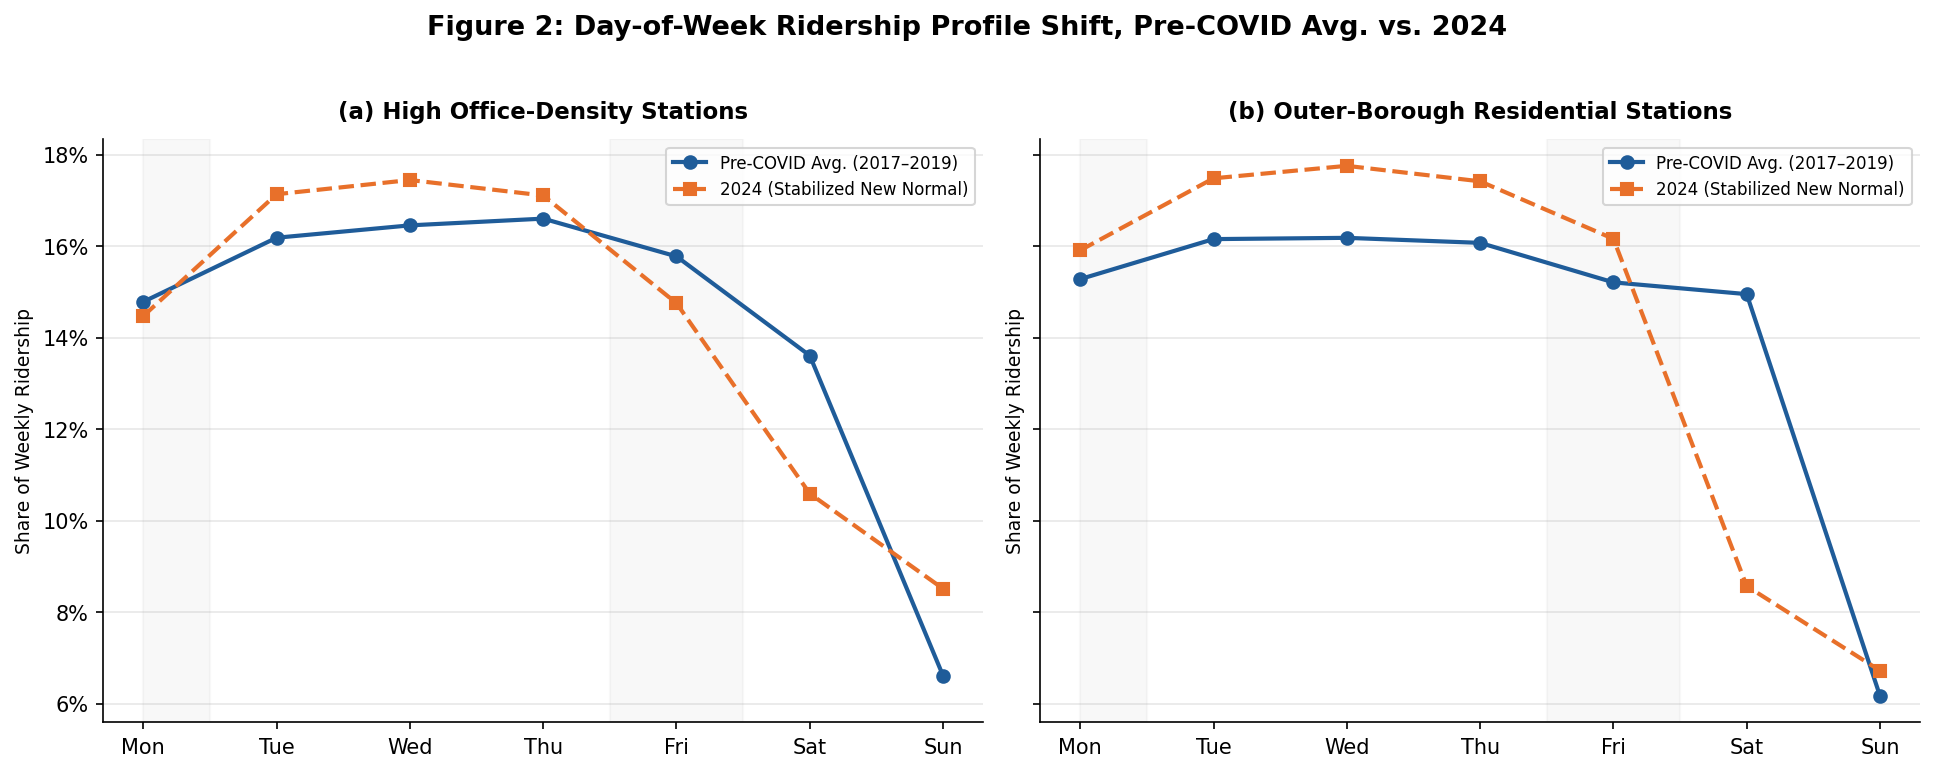


Figure 2 saved: /content/drive/MyDrive/dow_ridership_paper/outputs/figure2_dow_profile_shift_precovid_vs_2024.png


In [81]:
# ==============================================================
# Section 3.2 — Figure 2: Overlaid 7-Day Profiles
# Pre-COVID Average vs 2024
#
# Purpose:
#   Visualizes the structural shift in day-of-week ridership
#   profiles between the 2017–2019 pre-COVID average and 2024
#   for two contrasting station types:
#     (a) High office-density Manhattan stations
#     (b) Outer-borough residential stations
#
# Output:
#   figure2_dow_profile_shift_precovid_vs_2024.png
# ==============================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np
import re


# -------------------------------------------------------
# Required DOW labels
# -------------------------------------------------------

DOW_LABELS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]


# -------------------------------------------------------
# Representative stations
# These are search terms, not exact full names.
# The code below uses partial case-insensitive matching.
# -------------------------------------------------------

OFFICE_STATIONS = [
    "Grand Central",
    "Times Sq",
    "Rockefeller",
    "Herald Sq",
    "Fulton St",
]

RESIDENTIAL_STATIONS = [
    "Flatbush",
    "Pelham Bay",
    "Jamaica-179",
    "Bay Ridge",
    "Norwood",
]


# -------------------------------------------------------
# Fallback color palette
# -------------------------------------------------------

if "PALETTE" not in globals():
    PALETTE = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]


# -------------------------------------------------------
# Validate required inputs
# -------------------------------------------------------

required_periods = ["precovid", 2024]
missing_periods = [p for p in required_periods if p not in dow_raw]

if missing_periods:
    raise RuntimeError(
        f"dow_raw is missing required periods: {missing_periods}\n"
        f"Available keys: {list(dow_raw.keys())}\n"
        "Run Section 2.3 first."
    )

for period in required_periods:
    missing_cols = [c for c in ["complex_name"] + DOW_LABELS if c not in dow_raw[period].columns]
    if missing_cols:
        raise RuntimeError(
            f"dow_raw[{period!r}] is missing required columns: {missing_cols}\n"
            f"Columns found: {list(dow_raw[period].columns)}"
        )


# -------------------------------------------------------
# Helper: inspect available complex names
# -------------------------------------------------------

def show_name_matches(search_terms, df_key="precovid", max_matches=10):
    """
    Print possible complex-name matches for each search term.
    Useful for confirming that representative stations exist.
    """

    df = dow_raw[df_key].copy()

    print(f"\nChecking names in dow_raw[{df_key!r}]")

    for term in search_terms:
        pattern = re.escape(term)

        matches = (
            df.loc[
                df["complex_name"].astype(str).str.contains(pattern, case=False, na=False, regex=True),
                "complex_name"
            ]
            .drop_duplicates()
            .head(max_matches)
            .tolist()
        )

        print(f"\nSearch term: {term}")

        if matches:
            for m in matches:
                print(f"  {m}")
        else:
            print("  No matches found.")


# -------------------------------------------------------
# Helper: get matched stations
# -------------------------------------------------------

def get_matched_station_rows(period, station_terms: list[str]) -> pd.DataFrame:
    """
    Returns rows from dow_raw[period] whose complex_name partially matches
    any of the search terms.
    """

    df = dow_raw[period].copy()

    matched_frames = []

    for term in station_terms:
        pattern = re.escape(term)

        sub = df.loc[
            df["complex_name"].astype(str).str.contains(pattern, case=False, na=False, regex=True),
            ["station_complex_id", "complex_name"] + DOW_LABELS
        ].copy()

        if not sub.empty:
            sub["matched_term"] = term
            matched_frames.append(sub)

    if not matched_frames:
        return pd.DataFrame(columns=["station_complex_id", "complex_name", "matched_term"] + DOW_LABELS)

    matched = (
        pd.concat(matched_frames, ignore_index=True)
        .drop_duplicates(subset=["station_complex_id", "complex_name"])
        .reset_index(drop=True)
    )

    return matched


# -------------------------------------------------------
# Helper: get normalized DOW profile
# -------------------------------------------------------

def get_profile(period, station_terms: list[str], group_label: str) -> pd.Series:
    """
    Get normalized mean DOW profile across a set of station complexes.
    Uses partial case-insensitive matching.
    """

    matched = get_matched_station_rows(period, station_terms)

    if matched.empty:
        print(f"\nWarning: no matching stations for {group_label} in period {period}.")
        print(f"Search terms: {station_terms}")
        return pd.Series(index=DOW_LABELS, dtype=float)

    print(f"\nMatched stations for {group_label}, period {period}:")
    for name in matched["complex_name"].drop_duplicates().tolist():
        print(f"  {name}")

    profile = matched[DOW_LABELS].mean()

    total = profile.sum()

    if total <= 0 or pd.isna(total):
        print(f"\nWarning: profile total is zero/NaN for {group_label}, period {period}.")
        return pd.Series(index=DOW_LABELS, dtype=float)

    return profile / total


# -------------------------------------------------------
# Optional name check
# -------------------------------------------------------

print("\n================ FIGURE 2 NAME MATCH CHECKS ================\n")

show_name_matches(
    OFFICE_STATIONS + RESIDENTIAL_STATIONS,
    df_key="precovid"
)

show_name_matches(
    OFFICE_STATIONS + RESIDENTIAL_STATIONS,
    df_key=2024
)


# -------------------------------------------------------
# Build figure
# -------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

panel_specs = [
    {
        "terms": OFFICE_STATIONS,
        "title": "(a) High Office-Density Stations",
        "label": "office stations",
    },
    {
        "terms": RESIDENTIAL_STATIONS,
        "title": "(b) Outer-Borough Residential Stations",
        "label": "residential stations",
    },
]

for ax, spec in zip(axes, panel_specs):
    p_pre = get_profile(
        "precovid",
        spec["terms"],
        group_label=spec["label"]
    )

    p2024 = get_profile(
        2024,
        spec["terms"],
        group_label=spec["label"]
    )

    x = range(len(DOW_LABELS))

    ax.plot(
        x,
        p_pre,
        marker="o",
        linewidth=2,
        color=PALETTE[0],
        label="Pre-COVID Avg. (2017–2019)",
    )

    ax.plot(
        x,
        p2024,
        marker="s",
        linewidth=2,
        color=PALETTE[1],
        linestyle="--",
        label="2024 (Stabilized New Normal)",
    )

    ax.set_xticks(list(x))
    ax.set_xticklabels(DOW_LABELS)

    ax.set_title(
        spec["title"],
        fontsize=11,
        fontweight="bold",
        pad=10,
    )

    ax.set_ylabel("Share of Weekly Ridership", fontsize=9)

    ax.yaxis.set_major_formatter(
        mticker.PercentFormatter(xmax=1, decimals=0)
    )

    # Lightly shade Monday and Friday to highlight hybrid-work-relevant days
    ax.axvspan(0, 0.5, alpha=0.05, color="gray")
    ax.axvspan(3.5, 4.5, alpha=0.05, color="gray")

    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)


fig.suptitle(
    "Figure 2: Day-of-Week Ridership Profile Shift, Pre-COVID Avg. vs. 2024",
    fontsize=13,
    fontweight="bold",
    y=1.02,
)

plt.tight_layout()

fig_out = OUT_DIR / "figure2_dow_profile_shift_precovid_vs_2024.png"

plt.savefig(
    fig_out,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"\nFigure 2 saved: {fig_out}")


================ FIGURE 2 NAME MATCH CHECKS ================


Checking names in dow_raw['precovid']

Search term: Grand Central
  Grand Central-42 St (4,5,6,7,S)

Search term: Times Sq
  Times Sq-42 St/Port Authority Bus Terminal (1,2,3,7,A,C,E,N,Q,R,W,S)

Search term: Rockefeller
  No matches found.

Search term: Herald Sq
  34 St-Herald Sq (B,D,F,M,N,Q,R,W)

Search term: Fulton St
  Fulton St (2,3,4,5,A,C,J,Z)

Search term: Flatbush
  No matches found.

Search term: Pelham Bay
  Pelham Bay Park (6)

Search term: Jamaica-179
  Jamaica-179 St (F)

Search term: Bay Ridge
  Bay Ridge Av (R)
  Bay Ridge-95 St (R)

Search term: Norwood
  Norwood Av (J,Z)
  Norwood-205 St (D)

Checking names in dow_raw[2024]

Search term: Grand Central
  Grand Central-42 St (S,4,5,6,7)

Search term: Times Sq
  Times Sq-42 St (N,Q,R,W,S,1,2,3,7)/42 St (A,C,E)

Search term: Rockefeller
  47-50 Sts-Rockefeller Ctr (B,D,F,M)

Search term: Herald Sq
  34 St-Herald Sq (B,D,F,M,N,Q,R,W)

Search term: Fulton St
 

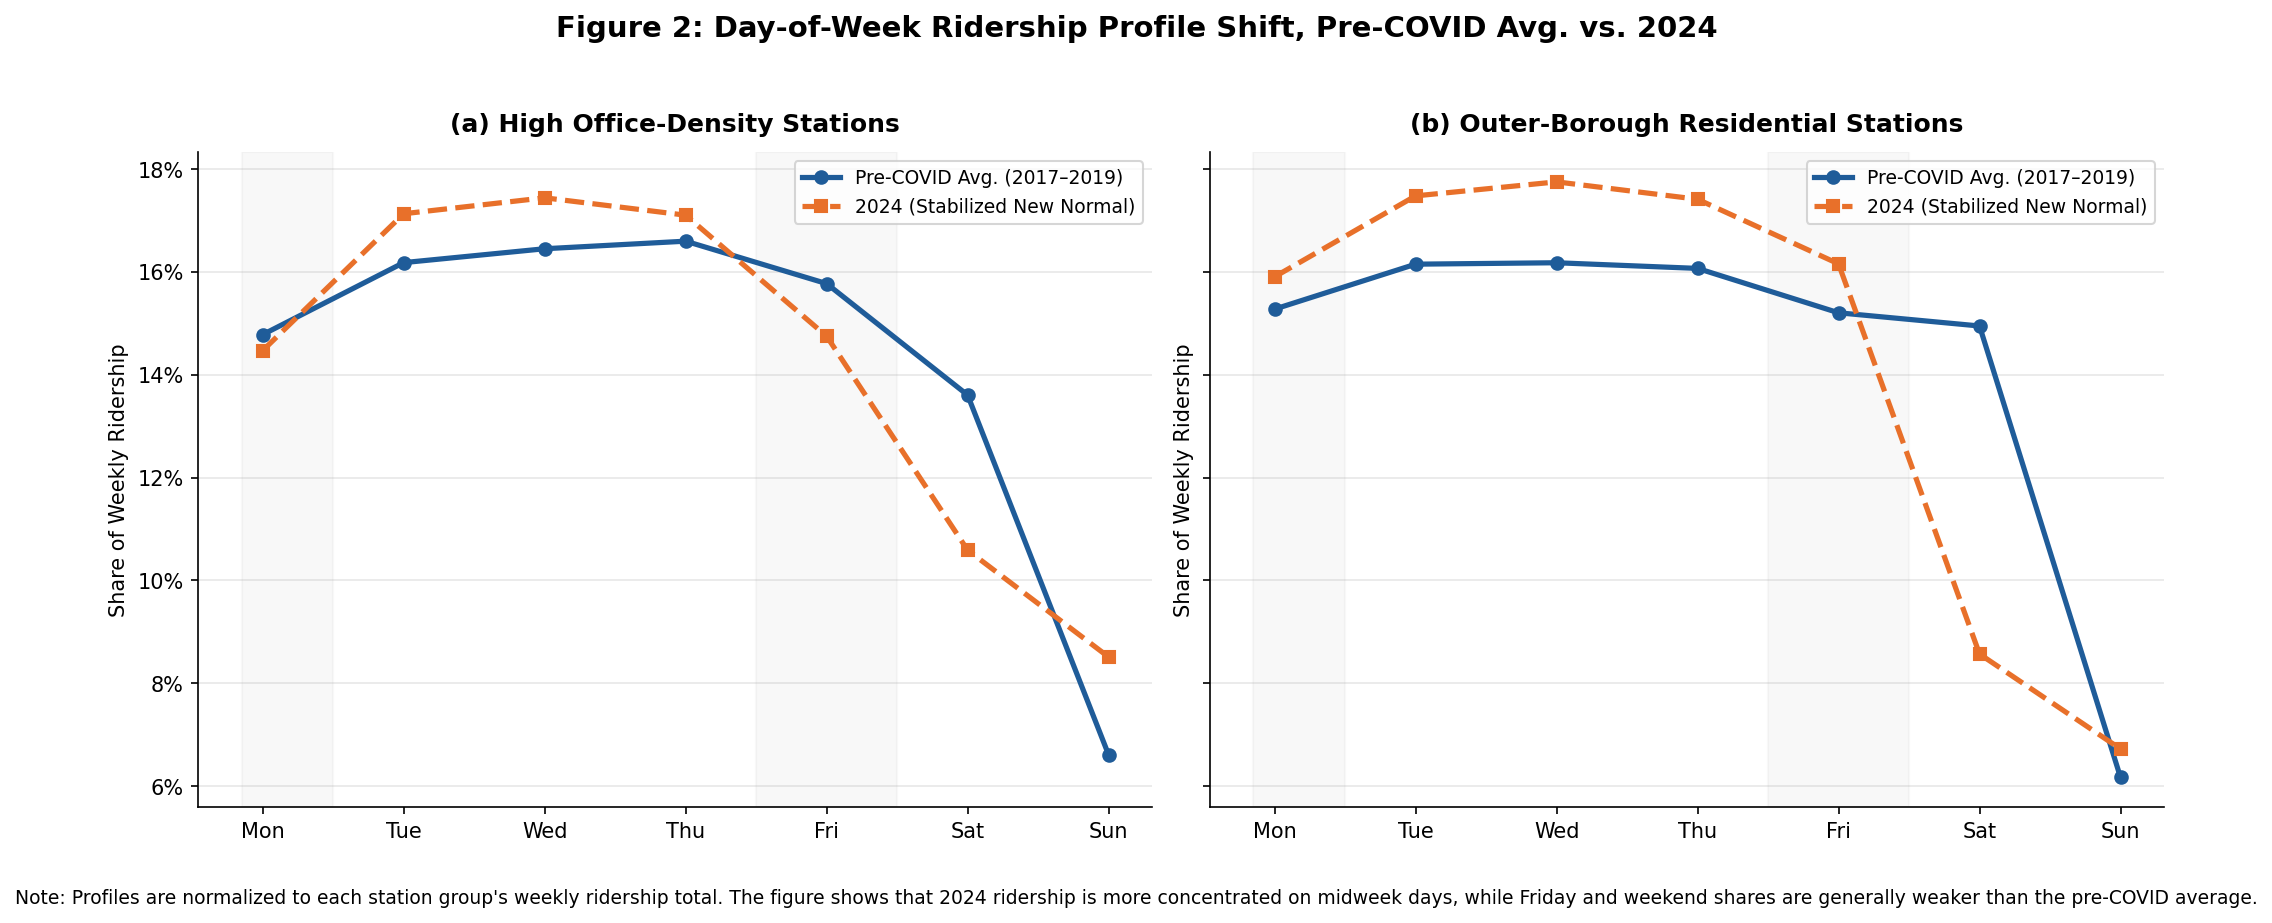


Figure 2 saved: /content/drive/MyDrive/dow_ridership_paper/outputs/figure2_dow_profile_shift_precovid_vs_2024.png


In [84]:
# ==============================================================
# Section 3.2 — Figure 2: Overlaid 7-Day Profiles
# Pre-COVID Average vs 2024
#
# Purpose:
#   Visualizes the structural shift in day-of-week ridership
#   profiles between the 2017–2019 pre-COVID average and 2024
#   for two contrasting station types:
#     (a) High office-density Manhattan stations
#     (b) Outer-borough residential stations
#
# Interpretation:
#   The figure highlights whether post-pandemic ridership is more
#   concentrated in the midweek and weaker on Fridays/weekends,
#   consistent with hybrid-work and changed non-work travel patterns.
#
# Output:
#   figure2_dow_profile_shift_precovid_vs_2024.png
# ==============================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np
import re


# -------------------------------------------------------
# Required DOW labels
# -------------------------------------------------------

DOW_LABELS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]


# -------------------------------------------------------
# Representative station search terms
# These are partial search terms, not exact full names.
# The code uses case-insensitive partial matching.
# -------------------------------------------------------

OFFICE_STATIONS = [
    "Grand Central",
    "Times Sq",
    "Rockefeller",
    "Herald Sq",
    "Fulton St",
]

RESIDENTIAL_STATIONS = [
    "Flatbush",
    "Pelham Bay",
    "Jamaica-179",
    "Bay Ridge",
    "Norwood",
]


# -------------------------------------------------------
# Fallback color palette
# -------------------------------------------------------

if "PALETTE" not in globals():
    PALETTE = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]


# -------------------------------------------------------
# Validate required inputs
# -------------------------------------------------------

required_periods = ["precovid", 2024]

missing_periods = [p for p in required_periods if p not in dow_raw]

if missing_periods:
    raise RuntimeError(
        f"dow_raw is missing required periods: {missing_periods}\n"
        f"Available keys: {list(dow_raw.keys())}\n"
        "Run Section 2.3 first."
    )

for period in required_periods:
    required_cols = ["station_complex_id", "complex_name"] + DOW_LABELS
    missing_cols = [c for c in required_cols if c not in dow_raw[period].columns]

    if missing_cols:
        raise RuntimeError(
            f"dow_raw[{period!r}] is missing required columns: {missing_cols}\n"
            f"Columns found: {list(dow_raw[period].columns)}"
        )


# -------------------------------------------------------
# Helper: inspect available complex names
# -------------------------------------------------------

def show_name_matches(search_terms, df_key="precovid", max_matches=10):
    """
    Print possible complex-name matches for each search term.
    Useful for confirming that representative stations exist.
    """

    df = dow_raw[df_key].copy()

    print(f"\nChecking names in dow_raw[{df_key!r}]")

    for term in search_terms:
        pattern = re.escape(term)

        matches = (
            df.loc[
                df["complex_name"]
                .astype(str)
                .str.contains(pattern, case=False, na=False, regex=True),
                "complex_name"
            ]
            .drop_duplicates()
            .head(max_matches)
            .tolist()
        )

        print(f"\nSearch term: {term}")

        if matches:
            for m in matches:
                print(f"  {m}")
        else:
            print("  No matches found.")


# -------------------------------------------------------
# Helper: get matched station rows
# -------------------------------------------------------

def get_matched_station_rows(period, station_terms: list[str]) -> pd.DataFrame:
    """
    Returns rows from dow_raw[period] whose complex_name partially matches
    any of the search terms.
    """

    df = dow_raw[period].copy()

    matched_frames = []

    for term in station_terms:
        pattern = re.escape(term)

        sub = df.loc[
            df["complex_name"]
            .astype(str)
            .str.contains(pattern, case=False, na=False, regex=True),
            ["station_complex_id", "complex_name"] + DOW_LABELS
        ].copy()

        if not sub.empty:
            sub["matched_term"] = term
            matched_frames.append(sub)

    if not matched_frames:
        return pd.DataFrame(
            columns=["station_complex_id", "complex_name", "matched_term"] + DOW_LABELS
        )

    matched = (
        pd.concat(matched_frames, ignore_index=True)
        .drop_duplicates(subset=["station_complex_id", "complex_name"])
        .reset_index(drop=True)
    )

    return matched


# -------------------------------------------------------
# Helper: get normalized DOW profile
# -------------------------------------------------------

def get_profile(period, station_terms: list[str], group_label: str) -> pd.Series:
    """
    Get normalized mean DOW profile across a set of station complexes.
    Uses partial case-insensitive matching.
    """

    matched = get_matched_station_rows(period, station_terms)

    if matched.empty:
        print(f"\nWarning: no matching stations for {group_label} in period {period}.")
        print(f"Search terms: {station_terms}")
        return pd.Series(index=DOW_LABELS, dtype=float)

    print(f"\nMatched stations for {group_label}, period {period}:")
    for name in matched["complex_name"].drop_duplicates().tolist():
        print(f"  {name}")

    profile = matched[DOW_LABELS].mean()
    total = profile.sum()

    if total <= 0 or pd.isna(total):
        print(f"\nWarning: profile total is zero/NaN for {group_label}, period {period}.")
        return pd.Series(index=DOW_LABELS, dtype=float)

    return profile / total


# -------------------------------------------------------
# Optional name checks
# -------------------------------------------------------

print("\n================ FIGURE 2 NAME MATCH CHECKS ================\n")

show_name_matches(
    OFFICE_STATIONS + RESIDENTIAL_STATIONS,
    df_key="precovid"
)

show_name_matches(
    OFFICE_STATIONS + RESIDENTIAL_STATIONS,
    df_key=2024
)


# -------------------------------------------------------
# Build profiles
# -------------------------------------------------------

office_pre = get_profile(
    "precovid",
    OFFICE_STATIONS,
    group_label="high office-density stations"
)

office_2024 = get_profile(
    2024,
    OFFICE_STATIONS,
    group_label="high office-density stations"
)

res_pre = get_profile(
    "precovid",
    RESIDENTIAL_STATIONS,
    group_label="outer-borough residential stations"
)

res_2024 = get_profile(
    2024,
    RESIDENTIAL_STATIONS,
    group_label="outer-borough residential stations"
)


# -------------------------------------------------------
# Build figure
# -------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

panel_specs = [
    {
        "ax": axes[0],
        "p_pre": office_pre,
        "p2024": office_2024,
        "title": "(a) High Office-Density Stations",
    },
    {
        "ax": axes[1],
        "p_pre": res_pre,
        "p2024": res_2024,
        "title": "(b) Outer-Borough Residential Stations",
    },
]

for spec in panel_specs:
    ax = spec["ax"]
    x = range(len(DOW_LABELS))

    ax.plot(
        x,
        spec["p_pre"],
        marker="o",
        linewidth=2.5,
        color=PALETTE[0],
        label="Pre-COVID Avg. (2017–2019)",
    )

    ax.plot(
        x,
        spec["p2024"],
        marker="s",
        linewidth=2.5,
        color=PALETTE[1],
        linestyle="--",
        label="2024 (Stabilized New Normal)",
    )

    ax.set_xticks(list(x))
    ax.set_xticklabels(DOW_LABELS)

    ax.set_title(
        spec["title"],
        fontsize=12,
        fontweight="bold",
        pad=10,
    )

    ax.set_ylabel("Share of Weekly Ridership", fontsize=10)

    ax.yaxis.set_major_formatter(
        mticker.PercentFormatter(xmax=1, decimals=0)
    )

    # Lightly shade Monday and Friday to highlight hybrid-work-relevant days
    ax.axvspan(-0.15, 0.5, alpha=0.05, color="gray")
    ax.axvspan(3.5, 4.5, alpha=0.05, color="gray")

    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)


# -------------------------------------------------------
# Title and interpretation note
# -------------------------------------------------------

fig.suptitle(
    "Figure 2: Day-of-Week Ridership Profile Shift, Pre-COVID Avg. vs. 2024",
    fontsize=14,
    fontweight="bold",
    y=1.03,
)

fig.text(
    0.5,
    -0.03,
    (
        "Note: Profiles are normalized to each station group's weekly ridership total. "
        "The figure shows that 2024 ridership is more concentrated on midweek days, "
        "while Friday and weekend shares are generally weaker than the pre-COVID average."
    ),
    ha="center",
    va="top",
    fontsize=9,
)


plt.tight_layout()


# -------------------------------------------------------
# Save figure
# -------------------------------------------------------

fig_out = OUT_DIR / "figure2_dow_profile_shift_precovid_vs_2024.png"

plt.savefig(
    fig_out,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"\nFigure 2 saved: {fig_out}")

In [86]:
# ==============================================================
# Section 3.3 — Monday/Friday vs. Tuesday–Thursday Recovery Gap
#
# Purpose:
#   Quantifies the "Mon/Fri gap" — the structural divergence
#   between Monday/Friday recovery and Tuesday–Thursday recovery.
#
# Main metric:
#   Recovery Rate = period mean entries / pre-COVID average mean entries
#
# Baseline:
#   Pre-COVID Avg. = 2017–2019 average
#
# Main comparison:
#   2022 = Early Recovery
#   2024 = Stabilized New Normal
#
# Robustness:
#   2023 = Transitional Recovery
#
# Outputs:
#   recovery_rates_by_dow.csv
#   recovery_gap_summary.csv
# ==============================================================

import pandas as pd
import numpy as np


# -------------------------------------------------------
# Required DOW labels and periods
# -------------------------------------------------------

DOW_LABELS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

PERIOD_LABELS = {
    "precovid": "Pre-COVID Avg. (2017–2019)",
    2022: "Early Recovery (2022)",
    2023: "Transitional Recovery (2023)",
    2024: "Stabilized New Normal (2024)",
}

RECOVERY_PERIODS = [2022, 2023, 2024]


# -------------------------------------------------------
# Validate inputs
# -------------------------------------------------------

required_periods = ["precovid"] + RECOVERY_PERIODS

missing_periods = [p for p in required_periods if p not in dow_raw]

if missing_periods:
    raise RuntimeError(
        f"dow_raw is missing required periods: {missing_periods}\n"
        f"Available keys: {list(dow_raw.keys())}\n"
        "Run Section 2.3 first."
    )

for period in required_periods:
    missing_cols = [c for c in DOW_LABELS if c not in dow_raw[period].columns]

    if missing_cols:
        raise RuntimeError(
            f"dow_raw[{period!r}] is missing DOW columns: {missing_cols}\n"
            f"Columns found: {list(dow_raw[period].columns)}"
        )


# -------------------------------------------------------
# Build recovery table by day of week
# -------------------------------------------------------

recovery_rows = []

for day in DOW_LABELS:
    baseline_mean = dow_raw["precovid"][day].mean()

    row = {
        "day": day,
        "baseline_mean_precovid": baseline_mean,
    }

    for period in RECOVERY_PERIODS:
        period_mean = dow_raw[period][day].mean()

        row[f"mean_{period}"] = period_mean

        row[f"recovery_{period}"] = (
            period_mean / baseline_mean
            if baseline_mean > 0
            else np.nan
        )

        row[f"pct_change_vs_precovid_{period}"] = (
            (period_mean - baseline_mean) / baseline_mean * 100
            if baseline_mean > 0
            else np.nan
        )

    recovery_rows.append(row)

recovery_df = (
    pd.DataFrame(recovery_rows)
    .set_index("day")
    .reindex(DOW_LABELS)
)


# -------------------------------------------------------
# Print recovery table with simple text bars
# -------------------------------------------------------

print("Recovery Rates by Day of Week")
print("Baseline: 2017–2019 Pre-COVID Average")
print("-" * 70)

for day, row in recovery_df.iterrows():
    print(f"\n{day}")

    for period in RECOVERY_PERIODS:
        recovery_value = row[f"recovery_{period}"]

        if pd.isna(recovery_value):
            bar = ""
            display_value = "NA"
        else:
            bar = "█" * int(recovery_value * 20)
            display_value = f"{recovery_value:5.1%}"

        print(
            f"  {period}: {display_value} {bar}"
        )


# -------------------------------------------------------
# Compute Mon/Fri vs Tue–Thu recovery gaps
# -------------------------------------------------------

gap_rows = []

for period in RECOVERY_PERIODS:
    monfri_recovery = recovery_df.loc[
        ["Mon", "Fri"],
        f"recovery_{period}"
    ].mean()

    tuethu_recovery = recovery_df.loc[
        ["Tue", "Wed", "Thu"],
        f"recovery_{period}"
    ].mean()

    weekend_recovery = recovery_df.loc[
        ["Sat", "Sun"],
        f"recovery_{period}"
    ].mean()

    gap = tuethu_recovery - monfri_recovery

    gap_rows.append(
        {
            "period": period,
            "period_label": PERIOD_LABELS[period],
            "monfri_recovery": monfri_recovery,
            "tuethu_recovery": tuethu_recovery,
            "weekend_recovery": weekend_recovery,
            "midweek_premium_over_monfri": gap,
        }
    )

gap_summary = pd.DataFrame(gap_rows)


# -------------------------------------------------------
# Print key findings
# -------------------------------------------------------

print("\n\nMon/Fri vs Tuesday–Thursday Recovery Gap")
print("Baseline: 2017–2019 Pre-COVID Average")
print("-" * 70)

for _, row in gap_summary.iterrows():
    print(f"\n{row['period_label']}")
    print(f"  Mon/Fri average recovery:       {row['monfri_recovery']:.1%}")
    print(f"  Tue–Thu average recovery:       {row['tuethu_recovery']:.1%}")
    print(f"  Weekend average recovery:       {row['weekend_recovery']:.1%}")
    print(
        f"  Midweek premium over Mon/Fri:   "
        f"{row['midweek_premium_over_monfri']:.1%}"
    )


# -------------------------------------------------------
# Save outputs
# -------------------------------------------------------

recovery_out = OUT_DIR / "recovery_rates_by_dow.csv"
gap_out = OUT_DIR / "recovery_gap_summary.csv"

recovery_df.to_csv(recovery_out)
gap_summary.to_csv(gap_out, index=False)

print("\nSaved outputs:")
print(f"  {recovery_out}")
print(f"  {gap_out}")


# -------------------------------------------------------
# Display clean tables
# -------------------------------------------------------

print("\nRecovery table preview:")
display(
    recovery_df[
        [
            "baseline_mean_precovid",
            "mean_2022",
            "recovery_2022",
            "mean_2023",
            "recovery_2023",
            "mean_2024",
            "recovery_2024",
        ]
    ].round(3)
)

print("\nGap summary:")
display(gap_summary.round(3))

Recovery Rates by Day of Week
Baseline: 2017–2019 Pre-COVID Average
----------------------------------------------------------------------

Mon
  2022: 44.7% ████████
  2023: 50.4% ██████████
  2024: 53.2% ██████████

Tue
  2022: 47.2% █████████
  2023: 54.2% ██████████
  2024: 55.8% ███████████

Wed
  2022: 47.4% █████████
  2023: 54.4% ██████████
  2024: 55.6% ███████████

Thu
  2022: 46.7% █████████
  2023: 53.3% ██████████
  2024: 54.8% ██████████

Fri
  2022: 46.2% █████████
  2023: 51.2% ██████████
  2024: 53.1% ██████████

Sat
  2022: 29.7% █████
  2023: 34.3% ██████
  2024: 35.9% ███████

Sun
  2022: 51.0% ██████████
  2023: 59.2% ███████████
  2024: 62.3% ████████████


Mon/Fri vs Tuesday–Thursday Recovery Gap
Baseline: 2017–2019 Pre-COVID Average
----------------------------------------------------------------------

Early Recovery (2022)
  Mon/Fri average recovery:       45.4%
  Tue–Thu average recovery:       47.1%
  Weekend average recovery:       40.3%
  Midweek premium o

,baseline_mean_precovid,mean_2022,recovery_2022,mean_2023,recovery_2023,mean_2024,recovery_2024
day,,,,,,,
Mon,"15,029.66","6,720.79",0.45,"7,573.35",0.50,"7,998.07",0.53
Tue,"16,187.48","7,638.53",0.47,"8,765.67",0.54,"9,029.35",0.56
Wed,"16,502.50","7,814.72",0.47,"8,983.06",0.54,"9,174.66",0.56
Thu,"16,594.26","7,753.20",0.47,"8,852.53",0.53,"9,095.57",0.55
Fri,"15,950.50","7,362.53",0.46,"8,159.32",0.51,"8,463.34",0.53
Sat,"16,199.50","4,807.51",0.30,"5,552.00",0.34,"5,822.25",0.36
Sun,"7,474.89","3,811.24",0.51,"4,424.93",0.59,"4,656.52",0.62



Gap summary:


,period,period_label,monfri_recovery,tuethu_recovery,weekend_recovery,midweek_premium_over_monfri
0,2022,Early Recovery (2022),0.45,0.47,0.40,0.02
1,2023,Transitional Recovery (2023),0.51,0.54,0.47,0.03
2,2024,Stabilized New Normal (2024),0.53,0.55,0.49,0.02


---
## SECTION 4: Cluster Analysis

### 4.1 K Selection: Elbow Method + Silhouette Score

We sweep K from 2 to 8. The optimal K is selected at the inflection point of the inertia curve (elbow method), validated by the silhouette score which measures cluster cohesion relative to separation.

K-selection input summary
--------------------------------------------------
Analysis year: 2024
Rows before low-volume filter: 426
Rows after low-volume filter:  426
Feature matrix shape:          (426, 7)

K-selection diagnostics
--------------------------------------------------
  K= 2  inertia=    1573.0  silhouette=0.3937
  K= 3  inertia=    1105.9  silhouette=0.3578
  K= 4  inertia=     912.5  silhouette=0.3715
  K= 5  inertia=     744.6  silhouette=0.3137
  K= 6  inertia=     653.7  silhouette=0.2858
  K= 7  inertia=     582.2  silhouette=0.3048
  K= 8  inertia=     528.2  silhouette=0.2683


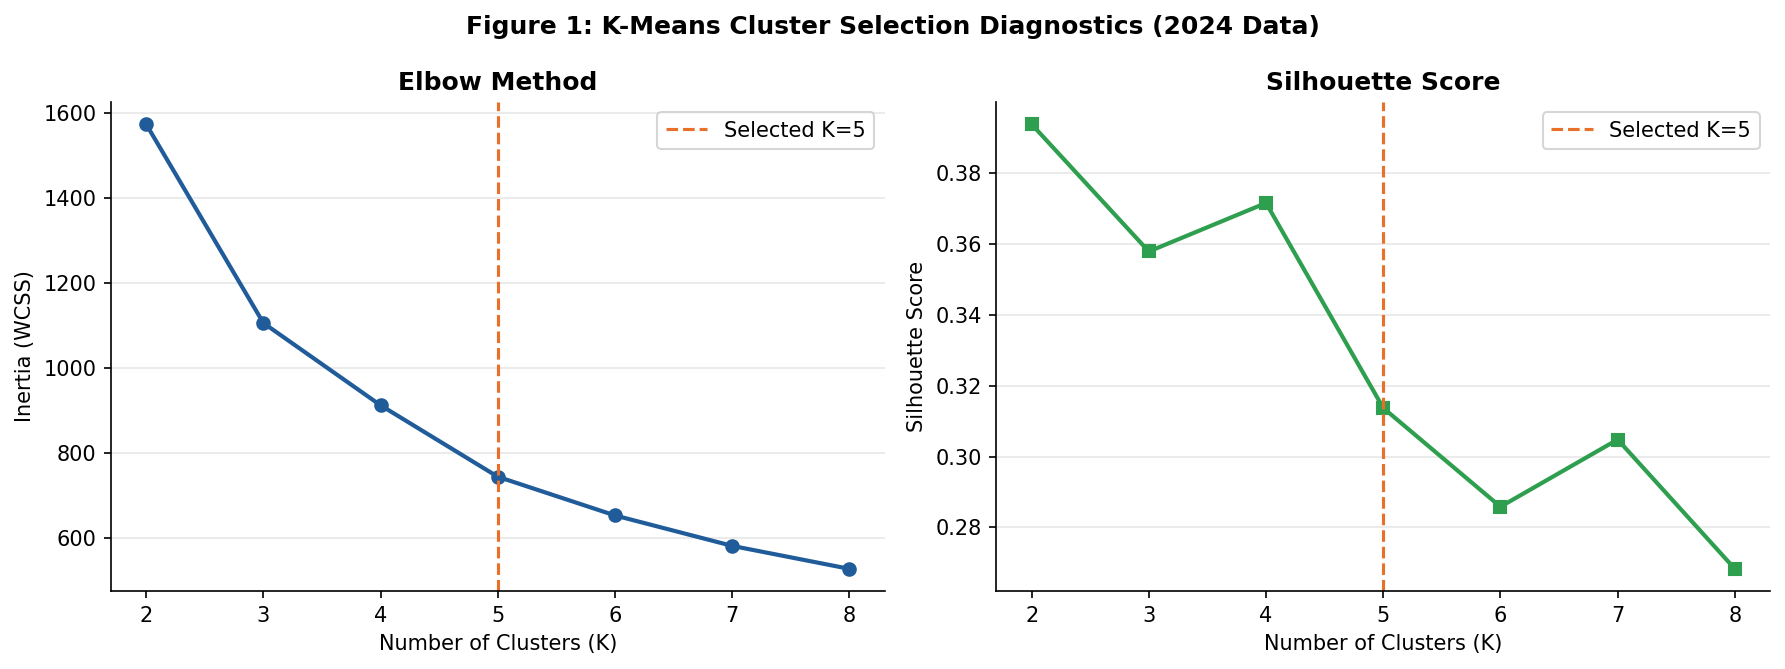


K-selection summary
--------------------------------------------------
Selected K_FINAL:                 5
Highest silhouette K:             2 (score=0.3937)
Diagnostics saved:                /content/drive/MyDrive/dow_ridership_paper/outputs/k_selection_diagnostics_2024.csv
Figure saved:                     /content/drive/MyDrive/dow_ridership_paper/outputs/figure1_k_selection_2024.png

Note: Use the silhouette peak together with the elbow plot and cluster interpretability. If diagnostics strongly favor a different K, update K_FINAL before running the final clustering section.


In [87]:
# ==============================================================
# Section 4.1 — K-Selection: Elbow + Silhouette
#
# Purpose:
#   Determines the optimal number of clusters K for K-means
#   applied to normalized 7-day DOW ridership vectors.
#
# Method:
#   - Primary clustering target: 2024 Stabilized New Normal
#   - Sweep K = 2..8
#   - Record inertia for elbow method
#   - Record silhouette score for each K
#   - Use K_FINAL as the selected value after inspection
#
# Input:
#   dow_vectors[2024]
#
# Outputs:
#   figure1_k_selection_2024.png
#   k_selection_diagnostics_2024.csv
# ==============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# -------------------------------------------------------
# Settings
# -------------------------------------------------------

CLUSTER_YEAR = 2024

DOW_LABELS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

if "K_RANGE" not in globals():
    K_RANGE = range(2, 9)

if "K_FINAL" not in globals():
    K_FINAL = 5

if "KMEANS_INIT" not in globals():
    KMEANS_INIT = 50

if "KMEANS_SEED" not in globals():
    KMEANS_SEED = 42

if "PALETTE" not in globals():
    PALETTE = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]


# -------------------------------------------------------
# Validate inputs
# -------------------------------------------------------

if "dow_vectors" not in globals():
    raise RuntimeError(
        "dow_vectors not found. Run Section 2.3 first."
    )

if CLUSTER_YEAR not in dow_vectors:
    raise RuntimeError(
        f"dow_vectors[{CLUSTER_YEAR}] not found.\n"
        f"Available keys: {list(dow_vectors.keys())}\n"
        "Run Section 2.3 first."
    )

cluster_df = dow_vectors[CLUSTER_YEAR].copy()

missing_cols = [c for c in DOW_LABELS if c not in cluster_df.columns]

if missing_cols:
    raise RuntimeError(
        f"dow_vectors[{CLUSTER_YEAR}] is missing DOW columns: {missing_cols}\n"
        f"Columns found: {list(cluster_df.columns)}"
    )

if "low_volume_flag" not in cluster_df.columns:
    print("Warning: low_volume_flag not found. Creating default False flag.")
    cluster_df["low_volume_flag"] = False


# -------------------------------------------------------
# Prepare feature matrix
# -------------------------------------------------------
# Exclude low-volume station complexes from clustering.

before_filter = len(cluster_df)

cluster_df = cluster_df[
    ~cluster_df["low_volume_flag"].fillna(False).astype(bool)
].copy()

after_filter = len(cluster_df)

if after_filter < 10:
    raise RuntimeError(
        f"Too few station complexes available for clustering: {after_filter}.\n"
        "Check Section 2.3 outputs."
    )

X = cluster_df[DOW_LABELS].astype(float).values

print("K-selection input summary")
print("-" * 50)
print(f"Analysis year: {CLUSTER_YEAR}")
print(f"Rows before low-volume filter: {before_filter:,}")
print(f"Rows after low-volume filter:  {after_filter:,}")
print(f"Feature matrix shape:          {X.shape}")


# -------------------------------------------------------
# Standardize features
# -------------------------------------------------------
# DOW vectors already sum to 1, but standardization gives each
# day equal influence in K-means distance calculations.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# -------------------------------------------------------
# K sweep
# -------------------------------------------------------

inertias = []
silhouettes = []

print("\nK-selection diagnostics")
print("-" * 50)

for k in K_RANGE:
    if k >= len(cluster_df):
        print(f"Skipping K={k}: K must be less than number of observations.")
        continue

    km = KMeans(
        n_clusters=k,
        n_init=KMEANS_INIT,
        random_state=KMEANS_SEED,
        max_iter=500,
    )

    labels = km.fit_predict(X_scaled)

    inertia = km.inertia_
    silhouette = silhouette_score(X_scaled, labels)

    inertias.append(inertia)
    silhouettes.append(silhouette)

    print(
        f"  K={k:2d}  "
        f"inertia={inertia:10.1f}  "
        f"silhouette={silhouette:.4f}"
    )


# -------------------------------------------------------
# Save diagnostics table
# -------------------------------------------------------

k_values = list(K_RANGE)[:len(inertias)]

k_diag = pd.DataFrame(
    {
        "k": k_values,
        "inertia": inertias,
        "silhouette": silhouettes,
    }
)

k_diag_out = OUT_DIR / f"k_selection_diagnostics_{CLUSTER_YEAR}.csv"
k_diag.to_csv(k_diag_out, index=False)


# -------------------------------------------------------
# Plot diagnostics
# -------------------------------------------------------

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot(
    k_diag["k"],
    k_diag["inertia"],
    "o-",
    color=PALETTE[0],
    linewidth=2,
)

ax1.axvline(
    K_FINAL,
    color=PALETTE[1],
    linestyle="--",
    label=f"Selected K={K_FINAL}",
)

ax1.set_xlabel("Number of Clusters (K)")
ax1.set_ylabel("Inertia (WCSS)")
ax1.set_title("Elbow Method", fontweight="bold")
ax1.legend()
ax1.grid(axis="y", alpha=0.3)


ax2.plot(
    k_diag["k"],
    k_diag["silhouette"],
    "s-",
    color=PALETTE[2],
    linewidth=2,
)

ax2.axvline(
    K_FINAL,
    color=PALETTE[1],
    linestyle="--",
    label=f"Selected K={K_FINAL}",
)

ax2.set_xlabel("Number of Clusters (K)")
ax2.set_ylabel("Silhouette Score")
ax2.set_title("Silhouette Score", fontweight="bold")
ax2.legend()
ax2.grid(axis="y", alpha=0.3)


plt.suptitle(
    f"Figure 1: K-Means Cluster Selection Diagnostics ({CLUSTER_YEAR} Data)",
    fontweight="bold",
)

plt.tight_layout()

fig_out = OUT_DIR / f"figure1_k_selection_{CLUSTER_YEAR}.png"

plt.savefig(
    fig_out,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# -------------------------------------------------------
# Report suggested K
# -------------------------------------------------------

best_silhouette_row = k_diag.loc[k_diag["silhouette"].idxmax()]

print("\nK-selection summary")
print("-" * 50)
print(f"Selected K_FINAL:                 {K_FINAL}")
print(
    f"Highest silhouette K:             "
    f"{int(best_silhouette_row['k'])} "
    f"(score={best_silhouette_row['silhouette']:.4f})"
)
print(f"Diagnostics saved:                {k_diag_out}")
print(f"Figure saved:                     {fig_out}")

print(
    "\nNote: Use the silhouette peak together with the elbow plot and "
    "cluster interpretability. If diagnostics strongly favor a different K, "
    "update K_FINAL before running the final clustering section."
)

In [88]:
# ==============================================================
# Section 4.2 — Final K-Means Fit
#
# Purpose:
#   Fits K-means with K=K_FINAL on normalized 7-day vectors
#   using 2024 as the primary clustering/training period.
#
# Important:
#   - Scaler is fit ONLY on 2024 data.
#   - K-means is fit ONLY on 2024 data.
#   - Pre-COVID, 2022, and 2023 vectors are transformed using
#     the same 2024-fitted scaler and assigned to the 2024
#     cluster structure for cross-period comparison.
#
# Baseline:
#   Pre-COVID Avg. = 2017–2019 average
#
# Main periods:
#   Pre-COVID Avg., 2022, 2024
#
# Robustness:
#   2023
#
# Outputs:
#   cluster_assignments_precovid.csv
#   cluster_assignments_2022.csv
#   cluster_assignments_2023.csv
#   cluster_assignments_2024.csv
#   cluster_centers_2024.csv
#   cluster_assignment_summary.csv
# ==============================================================

import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


# -------------------------------------------------------
# Settings
# -------------------------------------------------------

CLUSTER_YEAR = 2024
ASSIGNMENT_PERIODS = ["precovid", 2022, 2023, 2024]

DOW_LABELS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

if "K_FINAL" not in globals():
    K_FINAL = 5

if "KMEANS_INIT" not in globals():
    KMEANS_INIT = 50

if "KMEANS_SEED" not in globals():
    KMEANS_SEED = 42


# -------------------------------------------------------
# Validate inputs
# -------------------------------------------------------

if "dow_vectors" not in globals():
    raise RuntimeError(
        "dow_vectors not found. Run Section 2.3 first."
    )

missing_periods = [p for p in ASSIGNMENT_PERIODS if p not in dow_vectors]

if missing_periods:
    raise RuntimeError(
        f"dow_vectors is missing required periods: {missing_periods}\n"
        f"Available keys: {list(dow_vectors.keys())}\n"
        "Run Section 2.3 first."
    )

for period in ASSIGNMENT_PERIODS:
    missing_cols = [c for c in DOW_LABELS if c not in dow_vectors[period].columns]

    if missing_cols:
        raise RuntimeError(
            f"dow_vectors[{period!r}] is missing DOW columns: {missing_cols}\n"
            f"Columns found: {list(dow_vectors[period].columns)}"
        )

    if "low_volume_flag" not in dow_vectors[period].columns:
        print(f"Warning: low_volume_flag missing for {period}; setting to False.")
        dow_vectors[period]["low_volume_flag"] = False


# -------------------------------------------------------
# Prepare 2024 training data
# -------------------------------------------------------

train_df = dow_vectors[CLUSTER_YEAR].copy()

before_train = len(train_df)

train_df = train_df[
    ~train_df["low_volume_flag"].fillna(False).astype(bool)
].copy()

after_train = len(train_df)

if after_train < K_FINAL:
    raise RuntimeError(
        f"Too few 2024 station complexes for K={K_FINAL}: {after_train} rows."
    )

X_train = train_df[DOW_LABELS].astype(float).values

print("Final K-means training summary")
print("-" * 60)
print(f"Training period:              {CLUSTER_YEAR}")
print(f"K_FINAL:                      {K_FINAL}")
print(f"Rows before low-volume filter: {before_train:,}")
print(f"Rows after low-volume filter:  {after_train:,}")
print(f"Feature matrix shape:          {X_train.shape}")


# -------------------------------------------------------
# Fit scaler and final K-means on 2024 only
# -------------------------------------------------------

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

km_final = KMeans(
    n_clusters=K_FINAL,
    n_init=KMEANS_INIT,
    random_state=KMEANS_SEED,
    max_iter=1000,
)

km_final.fit(X_train_scaled)

print("\nFinal K-means model fit complete.")


# -------------------------------------------------------
# Save 2024 cluster centers in original DOW-share scale
# -------------------------------------------------------
# Cluster centers are fitted in standardized space. Convert them back
# to the original normalized DOW-share scale for interpretation.

centers_scaled = km_final.cluster_centers_
centers_original = scaler.inverse_transform(centers_scaled)

cluster_centers = pd.DataFrame(
    centers_original,
    columns=DOW_LABELS,
)

cluster_centers.insert(0, "cluster", range(K_FINAL))

# Normalize centers again for safety because inverse transform can create
# very small floating-point deviations from row sum = 1.
row_sums = cluster_centers[DOW_LABELS].sum(axis=1)

cluster_centers[DOW_LABELS] = cluster_centers[DOW_LABELS].div(
    row_sums,
    axis=0,
)

cluster_centers["weekday_share"] = cluster_centers[
    ["Mon", "Tue", "Wed", "Thu", "Fri"]
].sum(axis=1)

cluster_centers["weekend_share"] = cluster_centers[
    ["Sat", "Sun"]
].sum(axis=1)

cluster_centers["monfri_share"] = cluster_centers[
    ["Mon", "Fri"]
].sum(axis=1)

cluster_centers["tuethu_share"] = cluster_centers[
    ["Tue", "Wed", "Thu"]
].sum(axis=1)

cluster_centers["midweek_minus_monfri"] = (
    cluster_centers["tuethu_share"] -
    cluster_centers["monfri_share"]
)

centers_out = OUT_DIR / f"cluster_centers_{CLUSTER_YEAR}.csv"
cluster_centers.to_csv(centers_out, index=False)


# -------------------------------------------------------
# Assign clusters to each period
# -------------------------------------------------------

cluster_assignments = {}
summary_rows = []

for period in ASSIGNMENT_PERIODS:
    df_period = dow_vectors[period].copy()

    df_period = df_period[
        ~df_period["low_volume_flag"].fillna(False).astype(bool)
    ].copy()

    if df_period.empty:
        print(f"\nWarning: no rows available for period {period}. Skipping.")
        continue

    X_period = df_period[DOW_LABELS].astype(float).values
    X_period_scaled = scaler.transform(X_period)

    df_period["cluster"] = km_final.predict(X_period_scaled)
    df_period["period"] = period
    df_period["period_label"] = (
        "Pre-COVID Avg. (2017–2019)"
        if period == "precovid"
        else str(period)
    )

    # Add helpful profile metrics
    df_period["weekday_share"] = df_period[
        ["Mon", "Tue", "Wed", "Thu", "Fri"]
    ].sum(axis=1)

    df_period["weekend_share"] = df_period[
        ["Sat", "Sun"]
    ].sum(axis=1)

    df_period["monfri_share"] = df_period[
        ["Mon", "Fri"]
    ].sum(axis=1)

    df_period["tuethu_share"] = df_period[
        ["Tue", "Wed", "Thu"]
    ].sum(axis=1)

    df_period["midweek_minus_monfri"] = (
        df_period["tuethu_share"] -
        df_period["monfri_share"]
    )

    # Save assignment file
    period_file = "precovid" if period == "precovid" else str(period)
    cache = OUT_DIR / f"cluster_assignments_{period_file}.csv"

    df_period.to_csv(cache, index=False)

    cluster_assignments[period] = df_period

    dist = (
        df_period["cluster"]
        .value_counts()
        .sort_index()
        .to_dict()
    )

    print(f"\n{period}: cluster assignments saved")
    print(f"  File: {cache}")
    print(f"  Rows: {len(df_period):,}")
    print(f"  Distribution: {dist}")

    for cluster_id, count in dist.items():
        summary_rows.append(
            {
                "period": period,
                "period_label": df_period["period_label"].iloc[0],
                "cluster": cluster_id,
                "n_station_complexes": count,
                "share_of_period": count / len(df_period),
            }
        )


# -------------------------------------------------------
# Save cluster assignment summary
# -------------------------------------------------------

cluster_assignment_summary = pd.DataFrame(summary_rows)

summary_out = OUT_DIR / "cluster_assignment_summary.csv"

cluster_assignment_summary.to_csv(summary_out, index=False)

print("\nK-means fitting and cluster assignment complete.")
print(f"Cluster centers saved:      {centers_out}")
print(f"Assignment summary saved:   {summary_out}")


# -------------------------------------------------------
# Display summaries
# -------------------------------------------------------

print("\nCluster centers, original DOW-share scale:")
display(cluster_centers.round(4))

print("\nCluster assignment summary:")
display(cluster_assignment_summary.round(4))

Final K-means training summary
------------------------------------------------------------
Training period:              2024
K_FINAL:                      5
Rows before low-volume filter: 426
Rows after low-volume filter:  426
Feature matrix shape:          (426, 7)

Final K-means model fit complete.

precovid: cluster assignments saved
  File: /content/drive/MyDrive/dow_ridership_paper/outputs/cluster_assignments_precovid.csv
  Rows: 319
  Distribution: {0: 151, 1: 2, 2: 30, 3: 133, 4: 3}

2022: cluster assignments saved
  File: /content/drive/MyDrive/dow_ridership_paper/outputs/cluster_assignments_2022.csv
  Rows: 426
  Distribution: {0: 107, 1: 19, 2: 158, 3: 30, 4: 112}

2023: cluster assignments saved
  File: /content/drive/MyDrive/dow_ridership_paper/outputs/cluster_assignments_2023.csv
  Rows: 426
  Distribution: {0: 129, 1: 38, 2: 139, 3: 29, 4: 91}

2024: cluster assignments saved
  File: /content/drive/MyDrive/dow_ridership_paper/outputs/cluster_assignments_2024.csv
  Rows:

,cluster,Mon,Tue,Wed,Thu,Fri,Sat,Sun,weekday_share,weekend_share,monfri_share,tuethu_share,midweek_minus_monfri
0,0,0.14,0.16,0.16,0.16,0.16,0.12,0.09,0.79,0.21,0.30,0.49,0.19
1,1,0.15,0.18,0.18,0.18,0.15,0.09,0.07,0.84,0.16,0.30,0.54,0.25
2,2,0.15,0.17,0.17,0.17,0.16,0.10,0.08,0.82,0.18,0.32,0.51,0.19
3,3,0.13,0.15,0.15,0.15,0.15,0.14,0.12,0.74,0.26,0.29,0.45,0.16
4,4,0.16,0.18,0.18,0.18,0.17,0.08,0.06,0.86,0.14,0.33,0.53,0.20



Cluster assignment summary:


,period,period_label,cluster,n_station_complexes,share_of_period
0,precovid,Pre-COVID Avg. (2017–2019),0,151,0.47
1,precovid,Pre-COVID Avg. (2017–2019),1,2,0.01
2,precovid,Pre-COVID Avg. (2017–2019),2,30,0.09
3,precovid,Pre-COVID Avg. (2017–2019),3,133,0.42
4,precovid,Pre-COVID Avg. (2017–2019),4,3,0.01
5,2022,2022,0,107,0.25
6,2022,2022,1,19,0.04
7,2022,2022,2,158,0.37
8,2022,2022,3,30,0.07
9,2022,2022,4,112,0.26


In [ ]:
# ==============================================================
# Section 4.3 — Cluster Profile Analysis and Labeling
#
# Purpose:
#   Computes mean normalized DOW profile for each cluster
#   and generates interpretive labels based on profile shape.
#
# This produces Table 2 in the TRR paper.
#
# Cluster label logic (update after inspecting actual profiles):
#   - Sharp Tue–Thu peak + Mon/Fri near weekend levels → Hybrid Office Core
#   - Flat across all 7 days, stable → Essential/Residential Stable
#   - Weekend dominant, moderate weekday → Mixed-Use/Amenity
#   - Elevated all days, modest mid-week → Transit Hub
#   - Weekend > Mon/Fri → Emerging Weekend
# ==============================================================

# ---- Compute cluster centroids in original (non-scaled) normalized space ----
df_2024_clusters = cluster_assignments[2024].copy()

cluster_profiles = (
    df_2024_clusters
    .groupby("cluster")[DOW_LABELS]
    .mean()
    .round(4)
)

print("Table 2: Cluster Profiles — Mean Normalized Day-of-Week Ridership Share (2024)")
print(cluster_profiles.to_string())

# ---- Cluster size ----
cluster_sizes = df_2024_clusters["cluster"].value_counts().sort_index()
print("\nCluster sizes:")
print(cluster_sizes)

# ---- Assign interpretive labels ----
# NOTE: Update these labels based on actual profile inspection
CLUSTER_LABELS = {
    0: "Hybrid Office Core",
    1: "Essential/Residential Stable",
    2: "Mixed-Use / Amenity",
    3: "Transit Hub",
    4: "Emerging Weekend",
}

for yr in [2019, 2022, 2024]:
    cluster_assignments[yr]["cluster_label"] = (
        cluster_assignments[yr]["cluster"].map(CLUSTER_LABELS)
    )

cluster_profiles["cluster_label"] = cluster_profiles.index.map(CLUSTER_LABELS)
cluster_profiles.to_csv(OUT_DIR / "table2_cluster_profiles.csv")

# ---- Print representative stations per cluster ----
print("\nRepresentative Stations by Cluster (top 5 by avg weekday volume):")
for c_id, c_label in CLUSTER_LABELS.items():
    members = (
        df_2024_clusters[df_2024_clusters["cluster"] == c_id]
        .nlargest(5, "avg_weekday_entries")[["complex_name", "avg_weekday_entries"]]
    )
    print(f"\n  Cluster {c_id}: {c_label}")
    print(members.to_string(index=False))

In [ ]:
# ==============================================================
# Section 4.4 — Figure 3: Radar Chart of Cluster Profiles
#
# Purpose:
#   Visualizes the 7-day ridership profile for each cluster
#   as a radar/spider chart.
#   This becomes Figure 3 in the TRR paper.
# ==============================================================

import numpy as np

categories = DOW_LABELS
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the loop

fig, axes = plt.subplots(
    1, K_FINAL,
    figsize=(4 * K_FINAL, 4),
    subplot_kw=dict(polar=True)
)

for idx, (c_id, c_label) in enumerate(CLUSTER_LABELS.items()):
    ax = axes[idx]
    values = cluster_profiles.loc[c_id, DOW_LABELS].tolist()
    values += values[:1]  # close the loop

    ax.plot(angles, values, linewidth=2, color=PALETTE[idx])
    ax.fill(angles, values, alpha=0.20, color=PALETTE[idx])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=8)
    ax.set_yticklabels([])
    ax.set_title(
        f"Cluster {c_id}\n{c_label}",
        fontsize=9, fontweight="bold", pad=15
    )
    n_stations = cluster_sizes.get(c_id, 0)
    ax.text(0, 0, f"n={n_stations}", ha="center", va="center",
            fontsize=8, color="gray")

fig.suptitle(
    "Figure 3: Day-of-Week Demand Regime Profiles by Cluster (2024)",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.savefig(OUT_DIR / "figure3_radar_cluster_profiles.png",
            dpi=300, bbox_inches="tight")
plt.show()
print("Figure 3 saved.")

In [ ]:
# ==============================================================
# Section 4.5 — Cluster Transition Analysis (2019 → 2024)
#
# Purpose:
#   Tracks how stations migrated between demand regime clusters
#   from the pre-COVID baseline to the stabilized new normal.
#   Produces the transition matrix (Table 3 in the TRR paper).
#
# Method:
#   Inner join stations present in both 2019 and 2024;
#   cross-tabulate cluster assignments.
# ==============================================================

# ---- Merge 2019 and 2024 cluster assignments on station_complex_id ----
df_2019 = cluster_assignments[2019][["station_complex_id", "complex_name",
                                      "cluster", "cluster_label"]].copy()
df_2019 = df_2019.rename(columns={"cluster": "cluster_2019",
                                    "cluster_label": "label_2019"})

df_2024 = cluster_assignments[2024][["station_complex_id", "cluster",
                                      "cluster_label"]].copy()
df_2024 = df_2024.rename(columns={"cluster": "cluster_2024",
                                    "cluster_label": "label_2024"})

transitions = df_2019.merge(df_2024, on="station_complex_id", how="inner")

# ---- Transition matrix ----
transition_matrix = pd.crosstab(
    transitions["label_2019"],
    transitions["label_2024"],
    margins=True,
    margins_name="Total",
)

print("Table 3: Cluster Transition Matrix (2019 → 2024)")
print("Rows = 2019 cluster | Columns = 2024 cluster")
print(transition_matrix.to_string())

# ---- Stability metrics ----
n_stable = (transitions["cluster_2019"] == transitions["cluster_2024"]).sum()
n_total  = len(transitions)
pct_stable = n_stable / n_total * 100
print(f"\nStations in same cluster in both periods: {n_stable} / {n_total} ({pct_stable:.1f}%)")
print(f"Stations that migrated to a different cluster: {n_total - n_stable} ({100 - pct_stable:.1f}%)")

# ---- Identify biggest movers (most dramatic migrations) ----
migrants = transitions[
    transitions["cluster_2019"] != transitions["cluster_2024"]
].copy()

# Merge back with volume data to find high-volume migrants
migrants = migrants.merge(
    dow_raw[2024][["station_complex_id", "avg_weekday_entries"]],
    on="station_complex_id",
    how="left"
)
top_migrants = migrants.nlargest(10, "avg_weekday_entries")[
    ["complex_name", "label_2019", "label_2024", "avg_weekday_entries"]
]
print("\nTop 10 High-Volume Stations That Migrated Between Clusters:")
print(top_migrants.to_string(index=False))

transition_matrix.to_csv(OUT_DIR / "table3_transition_matrix.csv")
transitions.to_csv(OUT_DIR / "station_transitions.csv", index=False)

---
## SECTION 5: Regression Analysis

### 5.1 Built Environment Feature Engineering

Spatially join ACS block-group data and LODES job counts to each station's 0.5-mile catchment area. Aggregate demographic and employment variables to the station complex level.

In [ ]:
# ==============================================================
# Section 5.1 — Spatial Join: Built Environment → Stations
#
# Purpose:
#   Aggregates ACS and LODES data to station-level features
#   using 0.5-mile station buffers.
#
# Requires: geopandas, shapely
#
# Processing Steps:
#   1. Project station coordinates to NYC local CRS (EPSG:2263).
#   2. Buffer each station by 0.5 miles.
#   3. Spatially join Census block group geometries to buffers.
#   4. Compute area-weighted mean for population-based variables.
#   5. Sum job counts directly (jobs located within buffer).
#   6. Derive engineered features.
#
# Output:
#   station_features.csv
# ==============================================================

import geopandas as gpd
from shapely.geometry import Point

# ---- Build station GeoDataFrame ----
station_geo_df = cluster_assignments[2024][[
    "station_complex_id", "complex_name",
    "complex_lat", "complex_lon"
]].drop_duplicates().dropna(subset=["complex_lat", "complex_lon"])

station_gdf = gpd.GeoDataFrame(
    station_geo_df,
    geometry=gpd.points_from_xy(
        station_geo_df["complex_lon"],
        station_geo_df["complex_lat"]
    ),
    crs="EPSG:4326",
)

# Project to NYC State Plane (feet) for accurate buffering
station_gdf = station_gdf.to_crs("EPSG:2263")

# 0.5 mile in feet = 2640 feet
BUFFER_FT = CATCHMENT_MILES * 5280
station_buffers = station_gdf.copy()
station_buffers["geometry"] = station_gdf.geometry.buffer(BUFFER_FT)

print(f"Station buffers created: {len(station_buffers)} stations @ {CATCHMENT_MILES}-mile radius")

# ---- Load NYC Census block group geometries (TIGER/Line) ----
TIGER_URL = (
    "https://www2.census.gov/geo/tiger/TIGER2022/BG/tl_2022_36_bg.zip"
)
tiger_cache = OUT_DIR / "tl_2022_36_bg.zip"

if not tiger_cache.exists():
    print("Downloading NYC TIGER block group file...")
    resp = requests.get(TIGER_URL, timeout=120)
    resp.raise_for_status()
    tiger_cache.write_bytes(resp.content)

bg_gdf = gpd.read_file(f"zip://{tiger_cache}")
# Filter to NYC counties
bg_gdf = bg_gdf[
    (bg_gdf["STATEFP"] == "36") &
    (bg_gdf["COUNTYFP"].isin(["061", "005", "047", "081", "085"]))
].copy()
bg_gdf = bg_gdf.to_crs("EPSG:2263")
bg_gdf["GEOID"] = bg_gdf["GEOID"].astype(str).str.zfill(12)

print(f"NYC block groups loaded: {len(bg_gdf)}")

In [ ]:
# ==============================================================
# Section 5.2 — Feature Assembly
#
# Purpose:
#   Merges ACS + LODES data onto block group geometries,
#   performs spatial join to station buffers, and
#   aggregates to station-level features.
#
# Engineered features:
#   pct_no_vehicle   — % households with no vehicle
#   pct_transit_commute — % workers commuting by transit
#   office_job_density  — office jobs per acre in buffer
#   retail_job_density  — retail jobs per acre in buffer
#   essential_job_density — essential jobs per acre in buffer
#   log_office_jobs     — log1p(office_jobs) for skew correction
#   log_total_jobs      — log1p(total_jobs)
#   log_pop_density     — log1p(pop per acre)
#   log_median_income   — log1p(median_hh_income)
#
# Output:
#   station_features.csv
# ==============================================================

features_cache = OUT_DIR / "station_features.csv"

if features_cache.exists():
    station_features = pd.read_csv(features_cache)
    print("Station features loaded from cache.")
else:
    # ---- Merge ACS onto block groups ----
    acs_2022 = acs_data[2022].copy()
    lodes_2021 = lodes_data[2021].copy()

    bg_enriched = bg_gdf.merge(acs_2022, on="GEOID", how="left")
    bg_enriched = bg_enriched.merge(lodes_2021, on="GEOID", how="left")

    # ---- Spatial join: buffers ∩ block groups ----
    joined = gpd.sjoin(
        station_buffers[["station_complex_id", "geometry"]],
        bg_enriched,
        how="left",
        predicate="intersects"
    )

    # Compute buffer area for density calculation
    station_buffers["buffer_area_acres"] = (
        station_buffers.geometry.area / 43560  # sq ft → acres
    )

    # ---- Aggregate to station level ----
    agg = joined.groupby("station_complex_id").agg(
        total_population    = ("total_population",    "sum"),
        total_households    = ("total_households",    "sum"),
        no_vehicle_hh       = ("no_vehicle_hh",       "sum"),
        total_commuters     = ("total_commuters",     "sum"),
        transit_commuters   = ("transit_commuters",   "sum"),
        median_hh_income    = ("median_hh_income",    "median"),
        total_jobs          = ("total_jobs",          "sum"),
        office_jobs         = ("office_jobs",         "sum"),
        retail_jobs         = ("retail_jobs",         "sum"),
        essential_jobs      = ("essential_jobs",      "sum"),
    ).reset_index()

    # Merge buffer area
    agg = agg.merge(
        station_buffers[["station_complex_id", "buffer_area_acres"]],
        on="station_complex_id"
    )

    # ---- Derived features ----
    agg["pct_no_vehicle"] = (
        agg["no_vehicle_hh"] / agg["total_households"].replace(0, np.nan)
    )
    agg["pct_transit_commute"] = (
        agg["transit_commuters"] / agg["total_commuters"].replace(0, np.nan)
    )
    agg["pop_density"]           = agg["total_population"] / agg["buffer_area_acres"]
    agg["office_job_density"]    = agg["office_jobs"]  / agg["buffer_area_acres"]
    agg["retail_job_density"]    = agg["retail_jobs"]  / agg["buffer_area_acres"]
    agg["essential_job_density"] = agg["essential_jobs"] / agg["buffer_area_acres"]

    # Log transformations for skewed variables
    agg["log_office_jobs"]    = np.log1p(agg["office_jobs"])
    agg["log_total_jobs"]     = np.log1p(agg["total_jobs"])
    agg["log_pop_density"]    = np.log1p(agg["pop_density"])
    agg["log_median_income"]  = np.log1p(agg["median_hh_income"])

    agg.to_csv(features_cache, index=False)
    station_features = agg
    print(f"Station features assembled: {len(station_features)} stations")

print(station_features.describe().round(2).to_string())

In [ ]:
# ==============================================================
# Section 5.3 — Regression Model: Multinomial Logistic
#
# Purpose:
#   Explains cluster membership using built environment
#   features via multinomial logistic regression.
#
# Dependent variable: cluster label (0–K_FINAL-1), 2024 assignment
# Independent variables: log-transformed built environment features
# Reference category: Cluster 1 (Essential/Residential Stable)
#
# Estimation: statsmodels MNLogit for full coefficient table
#             with p-values and standard errors.
# Validation: 5-fold stratified cross-validation (sklearn)
#
# Output:
#   table4_regression_results.csv
# ==============================================================

# ---- Assemble regression dataset ----
reg_df = cluster_assignments[2024][[
    "station_complex_id", "complex_name", "cluster", "cluster_label"
]].merge(
    station_features,
    on="station_complex_id",
    how="inner"
)

print(f"Regression dataset: {len(reg_df)} stations")
print(f"Cluster distribution:\n{reg_df['cluster'].value_counts().sort_index()}")

# ---- Feature selection ----
FEATURE_COLS = [
    "log_office_jobs",
    "log_total_jobs",
    "log_pop_density",
    "log_median_income",
    "pct_no_vehicle",
    "pct_transit_commute",
    "retail_job_density",
    "essential_job_density",
]

# Drop rows with any missing feature
reg_df = reg_df.dropna(subset=FEATURE_COLS).copy()
print(f"After dropping NAs: {len(reg_df)} stations")

X_reg = reg_df[FEATURE_COLS].copy()
y_reg = reg_df["cluster"].copy()

# ---- Fit Multinomial Logit via statsmodels (for full output) ----
X_sm = sm.add_constant(X_reg)
mnlogit = sm.MNLogit(y_reg, X_sm)
result = mnlogit.fit(method="bfgs", maxiter=500, disp=False)

print("\nMultinomial Logit Results Summary:")
print(result.summary())

In [ ]:
# ==============================================================
# Section 5.4 — Regression Output Table (Table 4)
#
# Purpose:
#   Formats the multinomial logit coefficient table for
#   publication in TRR (Table 4).
#   Includes: coefficients, standard errors, p-values,
#   significance stars, and pseudo-R².
#
# Also runs 5-fold cross-validation for accuracy reporting.
# ==============================================================


def sig_stars(p: float) -> str:
    """Return significance stars for p-value."""
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    if p < 0.10:  return "†"
    return ""


# ---- Extract coefficient table ----
coef_tables = []

for outcome_idx in range(1, K_FINAL):  # MNLogit omits reference category (0)
    outcome_label = CLUSTER_LABELS.get(outcome_idx, f"Cluster {outcome_idx}")
    coefs  = result.params.iloc[:, outcome_idx - 1]
    pvals  = result.pvalues.iloc[:, outcome_idx - 1]
    bse    = result.bse.iloc[:, outcome_idx - 1]

    tbl = pd.DataFrame({
        "outcome":    outcome_label,
        "variable":   coefs.index,
        "coef":       coefs.values,
        "std_err":    bse.values,
        "p_value":    pvals.values,
        "stars":      [sig_stars(p) for p in pvals.values],
    })
    coef_tables.append(tbl)

all_coefs = pd.concat(coef_tables, ignore_index=True)
all_coefs["coef_str"] = (
    all_coefs["coef"].map("{:.3f}".format) +
    all_coefs["stars"]
)
all_coefs["se_str"] = "(" + all_coefs["std_err"].map("{:.3f}".format) + ")"

print("Table 4: Multinomial Logit Coefficients")
print(f"Reference category: {CLUSTER_LABELS[0]}")
print(f"Pseudo-R² (McFadden): {result.prsquared:.4f}")
print(f"Log-likelihood: {result.llf:.2f}")
print(f"N = {len(reg_df)}")
print()

pivot = all_coefs.pivot_table(
    index="variable", columns="outcome",
    values="coef_str", aggfunc="first"
)
print(pivot.to_string())

all_coefs.to_csv(OUT_DIR / "table4_regression_results.csv", index=False)

# ---- 5-Fold Cross-Validation (sklearn) ----
print("\nCross-Validation (5-fold, Stratified):")
lr = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=1000,
    C=1.0,
    random_state=KMEANS_SEED,
)
cv_pipe = Pipeline([("scaler", StandardScaler()), ("clf", lr)])
cv_scores = cross_val_score(
    cv_pipe, X_reg.values, y_reg.values,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=KMEANS_SEED),
    scoring="accuracy",
)
print(f"  Accuracy per fold: {[f'{s:.3f}' for s in cv_scores]}")
print(f"  Mean accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

---
## SECTION 6: Visualization for Publication

### 6.1 Figure 4: NYC Map — Stations Colored by Cluster Assignment

In [ ]:
# ==============================================================
# Section 6.1 — Figure 4: NYC Cluster Map
#
# Purpose:
#   Plots all subway station complexes on a NYC basemap,
#   colored by their 2024 cluster assignment.
#   This becomes Figure 4 in the TRR paper.
#
# Note: Uses geopandas for geometry and matplotlib for rendering.
#   For journal submission, export at 300 DPI as PNG or PDF.
# ==============================================================

# ---- Build GeoDataFrame for plotting ----
map_df = cluster_assignments[2024][[
    "station_complex_id", "complex_name",
    "complex_lat", "complex_lon",
    "cluster", "cluster_label",
]].dropna(subset=["complex_lat", "complex_lon"]).copy()

map_gdf = gpd.GeoDataFrame(
    map_df,
    geometry=gpd.points_from_xy(map_df["complex_lon"], map_df["complex_lat"]),
    crs="EPSG:4326"
)

# ---- NYC Borough boundaries (public domain) ----
NYC_BOROUGHS_URL = (
    "https://data.cityofnewyork.us/api/geospatial/7t3b-ywvw"
    "?method=export&type=GeoJSON"
)
boroughs_cache = OUT_DIR / "nyc_boroughs.geojson"
if not boroughs_cache.exists():
    resp = requests.get(NYC_BOROUGHS_URL, timeout=60)
    boroughs_cache.write_bytes(resp.content)

boroughs_gdf = gpd.read_file(boroughs_cache).to_crs("EPSG:4326")

# ---- Plot ----
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

boroughs_gdf.plot(
    ax=ax,
    color="#F5F5F0",
    edgecolor="#CCCCCC",
    linewidth=0.8,
)

for c_id, c_label in CLUSTER_LABELS.items():
    subset = map_gdf[map_gdf["cluster"] == c_id]
    subset.plot(
        ax=ax,
        color=PALETTE[c_id],
        markersize=18,
        alpha=0.85,
        label=f"Cluster {c_id}: {c_label} (n={len(subset)})",
        zorder=3,
    )

ax.set_axis_off()
ax.legend(
    loc="lower left",
    fontsize=9,
    framealpha=0.9,
    title="Day-of-Week Demand Regime",
    title_fontsize=9,
)
ax.set_title(
    "Figure 4: NYC Subway Station Demand Regime Clusters (2024)",
    fontsize=13, fontweight="bold", pad=15,
)

plt.tight_layout()
plt.savefig(OUT_DIR / "figure4_nyc_cluster_map.png",
            dpi=300, bbox_inches="tight")
plt.show()
print("Figure 4 saved.")

---
## SECTION 7: Robustness Checks

### 7.1 K Sensitivity — Re-run Clustering at K=3, 4, 6

TRR reviewers will ask whether results are sensitive to K selection. We rerun clustering at K±1 and K+1, check if major findings hold, and report silhouette scores.

In [ ]:
# ==============================================================
# Section 7.1 — Robustness: K Sensitivity Analysis
#
# Purpose:
#   Re-runs K-means at K = {K_FINAL-2, K_FINAL-1, K_FINAL+1}
#   and verifies that the Hybrid Office Core cluster
#   (sharp Tue–Thu peak with Mon/Fri collapse) persists
#   across all K specifications.
#
# Key robustness test: At any K, is there ALWAYS a cluster
#   where Mon + Fri share < (Tue + Wed + Thu share) / 3?
# ==============================================================

K_ROBUSTNESS = [K_FINAL - 2, K_FINAL - 1, K_FINAL + 1]
K_ROBUSTNESS = [k for k in K_ROBUSTNESS if k >= 2]  # ensure K >= 2

print("Robustness Check: K Sensitivity")
print("=" * 50)

for k_test in K_ROBUSTNESS:
    km_test = KMeans(
        n_clusters=k_test,
        n_init=KMEANS_INIT,
        random_state=KMEANS_SEED,
        max_iter=500,
    )
    labels_test = km_test.fit_predict(X_scaled)
    sil_test = silhouette_score(X_scaled, labels_test)

    # Compute centroids in normalized space
    test_df = cluster_df.copy()
    test_df["cluster_test"] = labels_test
    centroids_test = test_df.groupby("cluster_test")[DOW_LABELS].mean()

    # Check: does an office-core cluster exist?
    centroids_test["monfri_share"] = centroids_test[["Mon", "Fri"]].sum(axis=1)
    centroids_test["tuethu_share"] = centroids_test[["Tue", "Wed", "Thu"]].sum(axis=1)
    centroids_test["is_office_core"] = (
        centroids_test["tuethu_share"] > centroids_test["monfri_share"] * 1.15
    )

    n_office_core = centroids_test["is_office_core"].sum()
    print(f"\nK={k_test}: silhouette={sil_test:.4f} | "
          f"Office-core clusters detected: {n_office_core}")
    print(centroids_test[["Mon", "Tue", "Wed", "Thu", "Fri",
                           "monfri_share", "tuethu_share",
                           "is_office_core"]].round(3).to_string())

print("\nRobustness check complete.")

In [ ]:
# ==============================================================
# Section 7.2 — Robustness: Weekend Definition Sensitivity
#
# Purpose:
#   Tests whether conclusions change if Monday and Friday
#   are reclassified as "soft weekend" days and the analysis
#   is re-run with only Tue–Thu as "core weekdays".
#
# This directly supports the paper's argument that the
# weekday/weekend binary is no longer empirically valid.
# ==============================================================

# ---- Binary schedule test ----
# Under current MTA scheduling, Tue–Thu get the same
# headway/service as Mon and Fri.
# We test: is demand on Mon and Fri significantly different
# from Sat and Sun at Hybrid Office Core stations?

# Get Hybrid Office Core stations
office_core_ids = cluster_assignments[2024][
    cluster_assignments[2024]["cluster_label"] == "Hybrid Office Core"
]["station_complex_id"].unique()

office_raw_2024 = dow_raw[2024][
    dow_raw[2024]["station_complex_id"].isin(office_core_ids)
].copy()

# Paired t-test: Mon vs Sat at office-core stations
for day_a, day_b, description in [
    ("Mon", "Sat", "Mon vs Sat (office-core, 2024)"),
    ("Fri", "Sat", "Fri vs Sat (office-core, 2024)"),
    ("Tue", "Mon", "Tue vs Mon (office-core, 2024) — mid-week premium"),
]:
    t_stat, p_val = stats.ttest_rel(
        office_raw_2024[day_a].dropna(),
        office_raw_2024[day_b].dropna(),
    )
    direction = "higher" if t_stat > 0 else "lower"
    print(f"{description}")
    print(f"  t = {t_stat:.3f}, p = {p_val:.4f}  "
          f"({day_a} is {direction} than {day_b})")
    print()

---
## SECTION 8: Export and Paper Deliverables

Compiles all tables and figures into the final output folder for TRR submission.

In [ ]:
# ==============================================================
# Section 8.1 — Export Final Deliverables Summary
#
# Purpose:
#   Lists all outputs generated by this notebook and
#   confirms they are present in ./outputs/
# ==============================================================

DELIVERABLES = {
    "Tables": {
        "Table 1 — Summary Statistics": "table1_summary_stats.csv",
        "Table 2 — Cluster Profiles": "table2_cluster_profiles.csv",
        "Table 3 — Transition Matrix": "table3_transition_matrix.csv",
        "Table 4 — Regression Results": "table4_regression_results.csv",
    },
    "Figures": {
        "Figure 1 — K Selection Diagnostics": "figure1_k_selection.png",
        "Figure 2 — DOW Profile Shift 2019 vs 2024": "figure2_dow_profile_shift.png",
        "Figure 3 — Radar Chart Cluster Profiles": "figure3_radar_cluster_profiles.png",
        "Figure 4 — NYC Cluster Map": "figure4_nyc_cluster_map.png",
    },
    "Data": {
        "DOW Vectors 2019": "dow_vectors_2019.csv",
        "DOW Vectors 2022": "dow_vectors_2022.csv",
        "DOW Vectors 2024": "dow_vectors_2024.csv",
        "Cluster Assignments 2019": "cluster_assignments_2019.csv",
        "Cluster Assignments 2022": "cluster_assignments_2022.csv",
        "Cluster Assignments 2024": "cluster_assignments_2024.csv",
        "Station Features": "station_features.csv",
        "Station Transitions 2019→2024": "station_transitions.csv",
        "Recovery Rates by DOW": "recovery_rates_by_dow.csv",
    },
}

print("=" * 60)
print("DELIVERABLES CHECKLIST")
print("=" * 60)

all_present = True
for category, items in DELIVERABLES.items():
    print(f"\n{category}:")
    for label, filename in items.items():
        path = OUT_DIR / filename
        status = "✓" if path.exists() else "✗ MISSING"
        if not path.exists():
            all_present = False
        size = f"({path.stat().st_size:,} bytes)" if path.exists() else ""
        print(f"  [{status}] {label:45s} {size}")

print("\n" + "=" * 60)
if all_present:
    print("All deliverables present. Ready for TRR submission.")
else:
    print("Some deliverables are missing. Re-run relevant sections.")
print("=" * 60)

In [ ]:
# ==============================================================
# Section 8.2 — Key Findings Summary (For Paper Writing)
#
# Purpose:
#   Prints a structured summary of the key quantitative
#   findings for direct use in writing Results and
#   Discussion sections of the TRR paper.
# ==============================================================

print("=" * 60)
print("KEY FINDINGS SUMMARY FOR PAPER WRITING")
print("=" * 60)

print("\n[1] Day-of-Week Recovery Gap (2024 vs 2019):")
for day in DOW_LABELS:
    r = recovery_df.loc[day, "recovery_2024"]
    print(f"  {day}: {r:.1%}")

print(f"\n  Mon/Fri average recovery:  {monfri_2024:.1%}")
print(f"  Tue–Thu average recovery:  {tuethu_2024:.1%}")
print(f"  Mid-week premium:          {gap:.1%}")

print(f"\n[2] Cluster Analysis (K={K_FINAL}, 2024):")
for c_id, c_label in CLUSTER_LABELS.items():
    n = cluster_sizes.get(c_id, 0)
    pct = n / cluster_sizes.sum() * 100
    print(f"  Cluster {c_id} ({c_label}): {n} stations ({pct:.1f}%)")

print(f"\n[3] Cluster Transition (2019 → 2024):")
print(f"  Stations in same cluster:  {n_stable} / {n_total} ({pct_stable:.1f}%)")
print(f"  Stations that migrated:    {n_total - n_stable} ({100 - pct_stable:.1f}%)")

print(f"\n[4] Regression (Multinomial Logit):")
print(f"  Pseudo-R² (McFadden):      {result.prsquared:.4f}")
print(f"  5-fold CV accuracy:        {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print(f"  N (stations):              {len(reg_df)}")

print("\n" + "=" * 60)
print("Notebook execution complete.")
print("=" * 60)